Cell 0: Upload Spellman dataset in Colab

In [1]:
try:
    from google.colab import files
except ImportError:
    raise RuntimeError(
        "This cell is intended to run in Google Colab. "
        "If you are running locally, please place 'Spellman.csv' in the working directory."
    )

import os
import pandas as pd

DATA_FILENAME = "Spellman.csv"

# If the file is already in the working directory, skip upload
if DATA_FILENAME in os.listdir():
    print(f"[INFO] '{DATA_FILENAME}' already exists in the current directory. Skipping upload.")
else:
    print(f"[INFO] Please upload '{DATA_FILENAME}' now.")
    uploaded = files.upload()

    # Basic sanity check: make sure the required CSV is present
    if DATA_FILENAME not in uploaded:
        print(f"[WARNING] '{DATA_FILENAME}' was not found in the uploaded files.")
        print("Uploaded files:", list(uploaded.keys()))
    else:
        print(f"[INFO] '{DATA_FILENAME}' successfully uploaded and ready to load.")


[INFO] Please upload 'Spellman.csv' now.


Saving Spellman.csv to Spellman.csv
[INFO] 'Spellman.csv' successfully uploaded and ready to load.


Cell 1: Imports & global configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, SpectralBiclustering
from sklearn.metrics import silhouette_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GaussianNoise
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# -------------------------------------------------------------------
# Reproducibility: fix random seeds for NumPy and TensorFlow
# This is important so that clustering assignments and AE training
# are (approximately) repeatable across different runs.
# -------------------------------------------------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -------------------------------------------------------------------
# Global configuration / hyperparameters
# (used later in biclustering and autoencoder cells)
# -------------------------------------------------------------------

# Biclustering configuration
KR_CANDIDATES = list(range(3, 10))
KC_CANDIDATES = list(range(3, 10))
KR_DEFAULT        = 8                   # final choice for row clusters (genes)
KC_DEFAULT        = 6                   # final choice for column clusters (timepoints)
MSR_PERCENTILE    = 0.35                # fraction of best MSR biclusters marked as "valid"

# Gene filtering configuration
FILTER_FLAT_GENES     = True            # set False if you prefer to keep all genes
FLAT_GENE_PERCENTILE  = 0.2          # remove lowest 20% by variance in raw data

# Autoencoder (AE) configuration
# ------------------------------
AE_LATENT_DIM         = 3             # stronger compression than 6, still reasonable
AE_HIDDEN_DIM         = 32             # width of hidden layers
AE_NOISE_STD          = 0.2            # higher noise encourages more denoising
AE_LR                 = 1e-3            # learning rate for Adam
AE_EPOCHS             = 300             # max epochs; early stopping will stop earlier if converged
AE_BATCH_SIZE         = 64              # batch size for training
AE_VAL_SPLIT          = 0.10           # validation split fraction
AE_EARLY_STOP_PATIENCE = 15             # epochs to wait for val_loss improvement


# -------------------------------------------------------------------
# Matplotlib & Seaborn style for nicer plots
# -------------------------------------------------------------------
plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.1)

# Default figure size for all plots
plt.rcParams["figure.figsize"] = (6, 4)

# -------------------------------------------------------------------
# Show library versions (useful for debugging and reporting)
# -------------------------------------------------------------------
print("NumPy version      :", np.__version__)
print("Pandas version     :", pd.__version__)
print("Scikit-learn ver.  :", __import__('sklearn').__version__)
print("TensorFlow version :", tf.__version__)

# Optional: check whether a GPU is available for faster AE training
physical_gpus = tf.config.list_physical_devices("GPU")
if physical_gpus:
    print(f"[INFO] GPU detected ({len(physical_gpus)} device(s)) and will be used by TensorFlow.")
else:
    print("[INFO] No GPU detected, running on CPU.")

NumPy version      : 2.0.2
Pandas version     : 2.2.2
Scikit-learn ver.  : 1.6.1
TensorFlow version : 2.19.0
[INFO] GPU detected (1 device(s)) and will be used by TensorFlow.


Cell 2: Load Spellman dataset and basic inspection

In [3]:
import os

DATA_FILENAME = "Spellman.csv"

# -------------------------------------------------------------------
# Load the Spellman Yeast Cell-Cycle dataset.
# Assumption: 'Spellman.csv' is present in the current working directory
# (either uploaded in Cell 0 or already mounted).
# -------------------------------------------------------------------
if not os.path.exists(DATA_FILENAME):
    raise FileNotFoundError(
        f"'{DATA_FILENAME}' not found. "
        "Please ensure it is uploaded in Cell 0 or present in the working directory."
    )

df = pd.read_csv(DATA_FILENAME)

print("Raw data shape (rows, columns):", df.shape)
display(df.head())

# -------------------------------------------------------------------
# The 'time' column contains gene identifiers (e.g. 'YAL001C').
# All remaining columns correspond to time points (e.g. "40", "50", ..., "260").
# To be robust, we:
#   1) collect all non-'time' columns,
#   2) try to sort them numerically by their header (if headers are numeric strings),
#   3) reindex the DataFrame accordingly.
# -------------------------------------------------------------------
if "time" not in df.columns:
    raise ValueError("Expected a 'time' column with gene IDs, but it was not found in the CSV header.")

time_cols = [c for c in df.columns if c != "time"]

# Try to sort timepoint columns numerically (e.g. "40","50",..., "260")
try:
    time_cols_sorted = sorted(time_cols, key=lambda x: float(x))
except ValueError:
    # Fallback: keep original order if conversion to float fails
    time_cols_sorted = time_cols
    print("[WARNING] Could not sort timepoint columns numerically; using original column order.")

# Reorder columns: 'time' first, then the sorted timepoints
df = df[["time"] + time_cols_sorted]

# Extract gene IDs and timepoint labels
gene_ids = df["time"].values           # array of gene identifiers
timepoints = np.array(time_cols_sorted, dtype=str)  # keep as strings for plotting

print("Number of genes       :", len(gene_ids))
print("Number of time points :", len(timepoints))
print("Timepoints (ordered)  :", timepoints)

# -------------------------------------------------------------------
# Extract numeric expression matrix (genes x timepoints).
# Cast to float32 for compatibility with TensorFlow and to save memory.
# -------------------------------------------------------------------
X_raw = df.drop(columns=["time"]).astype(np.float32).values

print("Expression matrix shape (genes, timepoints):", X_raw.shape)

# Basic sanity check: matrix dimensions vs. labels
if X_raw.shape[0] != len(gene_ids) or X_raw.shape[1] != len(timepoints):
    raise RuntimeError(
        "Mismatch between extracted matrix dimensions and gene/timepoint labels "
        f"(matrix: {X_raw.shape}, genes: {len(gene_ids)}, timepoints: {len(timepoints)})."
    )


Raw data shape (rows, columns): (4381, 24)


,time,40,50,60,70,80,90,100,110,120,...,170,180,190,200,210,220,230,240,250,260
0,YAL001C,-0.070,-0.23,-0.100,0.03,-0.04,-0.12,-0.28,-0.44,-0.09,...,0.59,0.34,-0.28,-0.09,-0.44,0.31,0.03,0.57,0.00,0.010
1,YAL014C,0.215,0.09,0.025,-0.04,-0.04,-0.02,-0.51,-0.08,0.00,...,-0.30,-0.38,0.07,-0.04,0.13,-0.06,-0.26,-0.10,0.27,0.235
2,YAL016W,0.150,0.15,0.220,0.29,-0.10,0.15,-0.73,0.19,-0.15,...,0.12,-0.17,0.11,-0.15,0.03,-0.26,-0.34,-0.34,0.25,0.190
3,YAL020C,-0.350,-0.28,-0.215,-0.15,0.16,-0.12,0.26,0.00,0.13,...,0.07,0.61,-0.20,0.49,-0.43,0.80,-0.47,1.01,-0.36,-0.405
4,YAL022C,-0.415,-0.59,-0.580,-0.57,-0.09,-0.34,0.49,0.32,1.15,...,-0.48,-0.40,-0.59,0.54,-0.09,1.03,0.08,0.57,-0.26,-0.310


Number of genes       : 4381
Number of time points : 23
Timepoints (ordered)  : ['40' '50' '60' '70' '80' '90' '100' '110' '120' '130' '140' '150' '160'
 '170' '180' '190' '200' '210' '220' '230' '240' '250' '260']
Expression matrix shape (genes, timepoints): (4381, 23)


Cell 3: Check for NaN/Inf and basic statistics

Number of NaN values in X_raw : 0  (0.000000% of all entries)
Number of Inf values in X_raw : 0  (0.000000% of all entries)
[INFO] No NaN/Inf values found. No imputation is required.

Global statistics on raw expression values:
  Min    : -4.630000114440918
  Max    : 4.139999866485596
  Mean   : 0.0016867301892489195
  StdDev : 0.4245270788669586


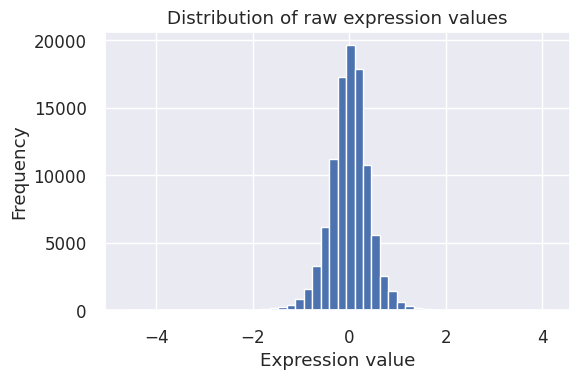

In [4]:
# -------------------------------------------------------------------
# 1) Check for missing (NaN) and infinite (Inf) values.
#    This directly corresponds to the "Preprocessing" requirements
#    in the project description.
# -------------------------------------------------------------------
n_nan = np.isnan(X_raw).sum()
n_inf = np.isinf(X_raw).sum()
n_total = X_raw.size

frac_nan = n_nan / n_total
frac_inf = n_inf / n_total

print(f"Number of NaN values in X_raw : {n_nan}  ({frac_nan:.6%} of all entries)")
print(f"Number of Inf values in X_raw : {n_inf}  ({frac_inf:.6%} of all entries)")

# Optionally, also report how many genes / timepoints are affected
if n_nan > 0 or n_inf > 0:
    nan_per_row = np.isnan(X_raw).any(axis=1)
    nan_per_col = np.isnan(X_raw).any(axis=0)
    inf_per_row = np.isinf(X_raw).any(axis=1)
    inf_per_col = np.isinf(X_raw).any(axis=0)

    n_genes_with_nan_or_inf = int((nan_per_row | inf_per_row).sum())
    n_tps_with_nan_or_inf   = int((nan_per_col | inf_per_col).sum())

    print(f"  Genes affected (NaN/Inf)      : {n_genes_with_nan_or_inf}")
    print(f"  Timepoints affected (NaN/Inf) : {n_tps_with_nan_or_inf}")

# -------------------------------------------------------------------
# 2) Optional imputation strategy.
# -------------------------------------------------------------------
if n_nan > 0 or n_inf > 0:
    print("[INFO] Detected NaN/Inf values. Applying simple row-wise mean imputation.")

    # Replace Inf with NaN so we treat all missing as NaN
    X_tmp = X_raw.copy()
    X_tmp[np.isinf(X_tmp)] = np.nan

    # Row-wise mean imputation:
    # For each gene (row), replace NaN entries with the mean of that row.
    row_means = np.nanmean(X_tmp, axis=1, keepdims=True)

    # If a row is entirely NaN, np.nanmean returns NaN; fall back to global mean.
    global_mean = np.nanmean(X_tmp)
    row_means = np.where(np.isnan(row_means), global_mean, row_means)

    # Broadcast means into NaN positions
    nan_mask = np.isnan(X_tmp)
    # nan_mask.any(axis=1) shape: (n_rows,), broadcast to columns via [:, None]
    X_tmp[nan_mask] = row_means[nan_mask.any(axis=1)][:, 0]

    X_raw = X_tmp.astype(np.float32)
    print("[INFO] Imputation completed.")

    # Sanity check: ensure no NaN/Inf remain
    if np.isnan(X_raw).sum() == 0 and np.isinf(X_raw).sum() == 0:
        print("[INFO] Post-imputation check passed: no NaN/Inf remain.")
    else:
        print("[WARNING] NaN/Inf still present after imputation. Please inspect X_raw manually.")
else:
    print("[INFO] No NaN/Inf values found. No imputation is required.")

# -------------------------------------------------------------------
# 3) Global statistics across the whole matrix.
# -------------------------------------------------------------------
print("\nGlobal statistics on raw expression values:")
print("  Min    :", float(np.min(X_raw)))
print("  Max    :", float(np.max(X_raw)))
print("  Mean   :", float(np.mean(X_raw)))
print("  StdDev :", float(np.std(X_raw)))

# -------------------------------------------------------------------
# 4) Plot histogram of all expression values to inspect the distribution.
# -------------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.hist(X_raw.flatten(), bins=50)
plt.xlabel("Expression value")
plt.ylabel("Frequency")
plt.title("Distribution of raw expression values")
plt.tight_layout()
plt.show()


Cell 4: Normalization (row-wise z-score per gene)

Normalized matrix shape (genes, timepoints): (4381, 23)
Row-wise mean (first 5 genes, should be ~0): [ 1.6966268e-08  1.0366025e-08 -2.5915063e-09  2.0732051e-08
  2.5915062e-08]
Row-wise std  (first 5 genes, should be ~1): [1.        0.9999999 0.9999999 1.        1.       ]

Row-wise variance (raw data) summary:
  min var  : 0.011631474830210209
  10% perc : 0.05268742889165878
  median   : 0.12433788925409317
  90% perc : 0.3333509564399719

[INFO] Filtering out lowest 20% genes by variance.
       Variance threshold = 6.970397e-02
       Removed genes      = 877 / 4381
New shape after filtering (genes, timepoints): (3504, 23)


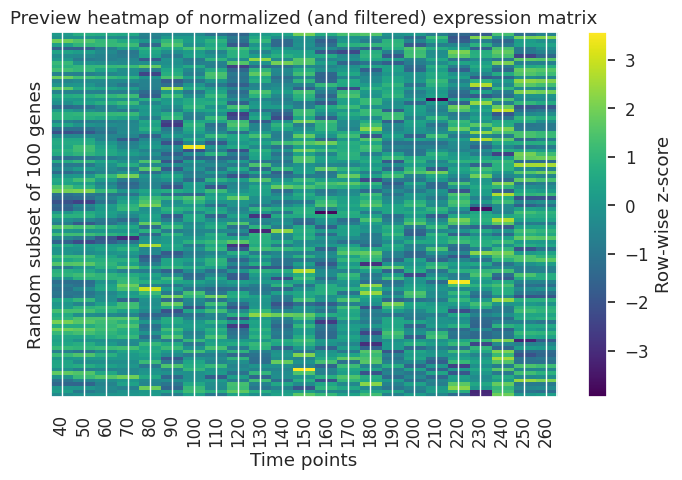

In [5]:
# -------------------------------------------------------------------
# 1) Row-wise z-score normalization (per gene)
#
# For each gene (row) we:
#   - subtract its mean across time points
#   - divide by its standard deviation across time points
#
# This emphasizes the *temporal pattern* of each gene (relative changes
# over the cell cycle) rather than its absolute expression level.
# This directly supports the project goal: biclustering should group
# genes with similar dynamic profiles, even if they differ in absolute
# expression.
# -------------------------------------------------------------------

# Compute row-wise statistics on the *raw* expression matrix
row_means = X_raw.mean(axis=1, keepdims=True)
row_stds  = X_raw.std(axis=1, keepdims=True)

# Small epsilon to avoid division by zero in case a gene is perfectly constant
eps = 1e-8
row_stds_safe = row_stds + eps

# Apply row-wise z-score normalization
X = (X_raw - row_means) / row_stds_safe

print("Normalized matrix shape (genes, timepoints):", X.shape)

# Quick sanity checks: first few rows should have mean ~0 and std ~1
print("Row-wise mean (first 5 genes, should be ~0):", X.mean(axis=1)[:5])
print("Row-wise std  (first 5 genes, should be ~1):", X.std(axis=1)[:5])

# -------------------------------------------------------------------
# 2) Inspect distribution of row variance before normalization.
#
# Some genes are almost flat (very low variance across time). These
# genes contribute little to biclustering and can introduce noise.
# We optionally remove the lowest-variance genes, controlled by the
# FILTER_FLAT_GENES / FLAT_GENE_PERCENTILE config (defined in Cell 1).
# -------------------------------------------------------------------
row_var_raw = X_raw.var(axis=1)

print("\nRow-wise variance (raw data) summary:")
print("  min var  :", float(row_var_raw.min()))
print("  10% perc :", float(np.quantile(row_var_raw, 0.10)))
print("  median   :", float(np.median(row_var_raw)))
print("  90% perc :", float(np.quantile(row_var_raw, 0.90)))

# Make sure config variables exist even if Cell 1 was not executed as expected
if "FILTER_FLAT_GENES" not in globals():
    FILTER_FLAT_GENES = False
if "FLAT_GENE_PERCENTILE" not in globals():
    FLAT_GENE_PERCENTILE = 0.10

if FILTER_FLAT_GENES:
    # Threshold for low-variance genes (e.g. bottom 10%)
    var_threshold = np.quantile(row_var_raw, FLAT_GENE_PERCENTILE)
    mask_informative = row_var_raw > var_threshold

    n_removed = int((~mask_informative).sum())
    n_total   = len(mask_informative)

    print(f"\n[INFO] Filtering out lowest {FLAT_GENE_PERCENTILE*100:.0f}% genes by variance.")
    print(f"       Variance threshold = {var_threshold:.6e}")
    print(f"       Removed genes      = {n_removed} / {n_total}")

    # Apply the mask to both X (normalized) and gene_ids
    X = X[mask_informative].astype(np.float32)
    gene_ids = gene_ids[mask_informative]

    print("New shape after filtering (genes, timepoints):", X.shape)
else:
    print("\n[INFO] FILTER_FLAT_GENES = False -> no genes were removed.")

# -------------------------------------------------------------------
# 3) Visual preview: heatmap of a random subset of genes.
#
# This helps verify that the normalized (and optionally filtered)
# matrix looks reasonable before applying biclustering.
# -------------------------------------------------------------------
n_genes, n_timepoints = X.shape
n_subset = min(100, n_genes)  # avoid errors if dataset is very small

subset_idx = np.random.choice(n_genes, size=n_subset, replace=False)

plt.figure(figsize=(7, 5))
plt.imshow(X[subset_idx, :], aspect="auto", cmap="viridis")

# Use actual timepoint labels on the x-axis if available
if "timepoints" in globals() and len(timepoints) == n_timepoints:
    plt.xticks(ticks=np.arange(n_timepoints), labels=timepoints, rotation=90)
else:
    plt.xticks([])

plt.yticks([])

plt.colorbar(label="Row-wise z-score")
plt.xlabel("Time points")
plt.ylabel(f"Random subset of {n_subset} genes")
plt.title("Preview heatmap of normalized (and filtered) expression matrix")
plt.tight_layout()
plt.show()


Cell 5: Helper functions (MSR, variance, plotting, evaluation)

In [6]:
def compute_msr(submatrix: np.ndarray) -> float:
    """
    Compute the Mean Squared Residue (MSR) for a bicluster (submatrix).

    MSR is defined (Cheng & Church) as:
        r_ij = a_ij - a_i. - a_.j + a_..
        MSR  = mean( r_ij^2 )

    where:
        a_ij   = entry in row i, column j
        a_i.   = mean of row i
        a_.j   = mean of column j
        a_..   = global mean of the bicluster

    Intuition:
        - MSR measures how well the bicluster can be explained by
          additive row and column effects.
        - Lower MSR ⇒ more coherent bicluster (stronger 2D pattern).

    Notes:
        - For biclusters with a single column (n_cols = 1), MSR is
          analytically zero, because row means and global mean coincide.
          Such biclusters are "perfect" under MSR but are usually not
          interesting for temporal patterns, so we often filter them out
          when visualizing top biclusters.
    """
    # Empty bicluster: return NaN as a sentinel value
    if submatrix.size == 0:
        return np.nan

    # Row and column means
    row_mean = submatrix.mean(axis=1, keepdims=True)
    col_mean = submatrix.mean(axis=0, keepdims=True)
    overall_mean = submatrix.mean()

    # Residues and MSR
    residues = submatrix - row_mean - col_mean + overall_mean
    msr = np.mean(residues ** 2)
    return float(msr)


def compute_variance(submatrix: np.ndarray) -> float:
    """
    Compute the variance of a bicluster (submatrix).

    Interpretation:
        - Higher variance ⇒ stronger overall signal amplitude
          (expression values deviate more from the mean).
        - Together with MSR, variance helps distinguish biclusters
          that are homogeneous but "flat" from those that show
          strong, coherent regulation patterns.
    """
    if submatrix.size == 0:
        return np.nan
    # Population variance (ddof=0)
    return float(np.var(submatrix))


def evaluate_biclusters(
    X: np.ndarray,
    row_labels,
    col_labels,
    kr: int,
    kc: int
) -> pd.DataFrame:
    """
    Evaluate all kr * kc biclusters in terms of MSR and variance.

    Parameters
    ----------
    X : 2D np.ndarray
        Normalized gene expression matrix (genes x timepoints).
    row_labels : array-like of shape (n_genes,)
        Cluster labels for each gene.
    col_labels : array-like of shape (n_timepoints,)
        Cluster labels for each timepoint.
    kr : int
        Number of row clusters (genes).
    kc : int
        Number of column clusters (timepoints).

    Returns
    -------
    pandas.DataFrame
        One row per bicluster, with columns:
        - 'row_cluster' : row cluster index (0..kr-1)
        - 'col_cluster' : column cluster index (0..kc-1)
        - 'n_rows'      : number of genes in the bicluster
        - 'n_cols'      : number of timepoints in the bicluster
        - 'msr'         : Mean Squared Residue
        - 'var'         : variance of entries in the bicluster
    """
    X = np.asarray(X)
    if X.ndim != 2:
        raise ValueError(f"X must be a 2D array, got shape {X.shape}")

    row_labels = np.asarray(row_labels)
    col_labels = np.asarray(col_labels)

    n_genes, n_timepoints = X.shape
    if row_labels.shape[0] != n_genes:
        raise ValueError("row_labels length does not match number of rows in X.")
    if col_labels.shape[0] != n_timepoints:
        raise ValueError("col_labels length does not match number of columns in X.")

    results = []
    for r in range(kr):
        row_idx = np.where(row_labels == r)[0]
        for c in range(kc):
            col_idx = np.where(col_labels == c)[0]

            # Handle completely empty clusters (should not happen in practice,
            # but this keeps the function robust to pathological cases).
            if len(row_idx) == 0 or len(col_idx) == 0:
                results.append({
                    "row_cluster": r,
                    "col_cluster": c,
                    "n_rows": int(len(row_idx)),
                    "n_cols": int(len(col_idx)),
                    "msr": np.nan,
                    "var": np.nan,
                })
                continue

            sub = X[np.ix_(row_idx, col_idx)]
            msr = compute_msr(sub)
            var = compute_variance(sub)

            results.append({
                "row_cluster": r,
                "col_cluster": c,
                "n_rows": int(len(row_idx)),
                "n_cols": int(len(col_idx)),
                "msr": msr,
                "var": var,
            })

    return pd.DataFrame(results)


def plot_heatmap(
    X: np.ndarray,
    title: str = "",
    x_ticklabels=None,
    y_ticklabels=None,
    figsize=(6, 5),
    cmap: str = "viridis"
):
    """
    Generic heatmap plotting utility for 2D matrices.
    Can be used for:
        - the full expression matrix, or
        - individual biclusters.

    Parameters
    ----------
    X : np.ndarray
        Matrix to visualize (2D).
    title : str
        Title of the plot.
    x_ticklabels : list-like or None
        Labels for the x-axis; if provided and length matches n_cols,
        they will be shown, otherwise ticks are hidden.
    y_ticklabels : list-like or None
        Labels for the y-axis; if provided and length matches n_rows,
        they will be shown, otherwise ticks are hidden.
    figsize : tuple
        Figure size in inches.
    cmap : str
        Matplotlib colormap name.
    """
    X = np.asarray(X)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D for heatmap, got shape {X.shape}")

    plt.figure(figsize=figsize)
    im = plt.imshow(X, aspect="auto", cmap=cmap)
    plt.colorbar(im, label="Expression (normalized)")

    # X-axis labels (timepoints)
    if x_ticklabels is not None and len(x_ticklabels) == X.shape[1]:
        plt.xticks(ticks=np.arange(X.shape[1]), labels=x_ticklabels, rotation=90)
    else:
        plt.xticks([])

    # Y-axis labels (gene indices or IDs)
    if y_ticklabels is not None and len(y_ticklabels) == X.shape[0]:
        plt.yticks(ticks=np.arange(X.shape[0]), labels=y_ticklabels)
    else:
        plt.yticks([])

    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_top_biclusters(
    X: np.ndarray,
    row_labels,
    col_labels,
    results_df: pd.DataFrame,
    top_n: int = 5,
    title_prefix: str = "Hierarchical",
    min_rows: int = 1,
    min_cols: int = 2
):
    """
    Plot heatmaps for the top_n biclusters with the smallest MSR.

    By default we require at least 'min_cols = 2' timepoints in a bicluster.
    This avoids trivial single-column biclusters with MSR = 0 that are
    mathematically perfect but not informative for temporal pattern analysis.

    Parameters
    ----------
    X : np.ndarray
        Full expression matrix (normalized or denoised).
    row_labels, col_labels : array-like
        Cluster assignments for rows and columns (same as used in evaluate_biclusters).
    results_df : pd.DataFrame
        Output of evaluate_biclusters (contains msr, var, n_rows, n_cols).
    top_n : int
        Number of best biclusters (lowest MSR) to visualize.
    title_prefix : str
        Prefix added to the title of each bicluster heatmap
        (e.g. 'Hierarchical', 'Spectral').
    min_rows : int
        Minimum number of rows (genes) for a bicluster to be considered for plotting.
    min_cols : int
        Minimum number of columns (timepoints) for a bicluster to be considered for plotting.
    """
    # Filter biclusters that are too small or have NaN MSR
    valid_bc = results_df.copy()
    valid_bc = valid_bc.dropna(subset=["msr"])
    valid_bc = valid_bc[
        (valid_bc["n_rows"] >= min_rows) &
        (valid_bc["n_cols"] >= min_cols)
    ]

    if valid_bc.empty:
        print("[WARNING] No biclusters satisfy the size/MSR constraints for plotting.")
        return

    # Select top_n biclusters with the smallest MSR among the filtered set
    top = valid_bc.sort_values("msr").head(top_n)

    for _, row in top.iterrows():
        r = int(row["row_cluster"])
        c = int(row["col_cluster"])
        row_idx = np.where(row_labels == r)[0]
        col_idx = np.where(col_labels == c)[0]
        sub = X[np.ix_(row_idx, col_idx)]

        title = (
            f"{title_prefix} BC (row={r}, col={c}) | "
            f"rows={len(row_idx)}, cols={len(col_idx)}\n"
            f"MSR={row['msr']:.4f}, Var={row['var']:.4f}"
        )

        plot_heatmap(sub, title=title, figsize=(4, 4))


Cell 6: Biclustering helper functions (Hierarchical & Spectral)

In [7]:
from typing import Tuple

def run_hierarchical_biclustering(
    X: np.ndarray,
    kr: int,
    kc: int,
    linkage: str = "ward",
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Perform hierarchical biclustering by clustering rows and columns separately.

    This implements a *two-way clustering*:
      - rows (genes) are clustered using AgglomerativeClustering
      - columns (time points) are clustered independently, on X^T

    In the context of this homework:
      - X is the normalized (row-wise z-scored) gene expression matrix.
      - kr is the number of gene clusters (row clusters).
      - kc is the number of timepoint clusters (column clusters).
      - The resulting reordered matrix highlights rectangular biclusters.

    Parameters
    ----------
    X : np.ndarray of shape (n_genes, n_timepoints)
        Normalized expression matrix (each row z-scored across timepoints).
    kr : int
        Number of row clusters (genes).
    kc : int
        Number of column clusters (timepoints).
    linkage : str, default "ward"
        Linkage criterion for AgglomerativeClustering
        (e.g. "ward", "average", "complete").
        Note: "ward" requires Euclidean distances.

    Returns
    -------
    row_labels : np.ndarray of shape (n_genes,)
        Cluster labels for all rows (genes).
    col_labels : np.ndarray of shape (n_timepoints,)
        Cluster labels for all columns (timepoints).
    row_order : np.ndarray
        Indices that sort rows by cluster label (useful for heatmaps).
    col_order : np.ndarray
        Indices that sort columns by cluster label.
    X_reordered : np.ndarray of shape (n_genes, n_timepoints)
        Matrix reordered by row and column clusters.
    """
    X = np.asarray(X)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got shape {X.shape}")
    n_genes, n_timepoints = X.shape

    if kr <= 0 or kc <= 0:
        raise ValueError("kr and kc must be positive integers.")

    # AgglomerativeClustering in recent scikit-learn versions uses 'metric'
    # instead of 'affinity'. For 'ward' linkage, the metric must be Euclidean.
    metric = "euclidean" if linkage == "ward" else "euclidean"

    # --- Cluster genes (rows) ---
    row_clust = AgglomerativeClustering(
        n_clusters=kr,
        linkage=linkage,
        metric=metric,
    )
    row_labels = row_clust.fit_predict(X)   # shape: (n_genes,)

    # --- Cluster timepoints (columns) ---
    # We cluster columns by clustering the transposed matrix X^T.
    col_clust = AgglomerativeClustering(
        n_clusters=kc,
        linkage=linkage,
        metric=metric,
    )
    col_labels = col_clust.fit_predict(X.T)  # shape: (n_timepoints,)

    # --- Compute reorder indices for visualization ---
    row_order = np.argsort(row_labels)
    col_order = np.argsort(col_labels)

    X_reordered = X[row_order][:, col_order]

    return row_labels, col_labels, row_order, col_order, X_reordered


def run_spectral_biclustering(
    X: np.ndarray,
    kr: int,
    kc: int,
    method: str = "bistochastic",
    random_state: int = SEED,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Perform Spectral Biclustering using scikit-learn.

    This provides an alternative biclustering model to the hierarchical
    approach. The algorithm simultaneously groups rows and columns by
    exploiting the spectral structure of the matrix.

    In the context of this homework:
      - We apply SpectralBiclustering to the same normalized matrix X.
      - We use the same (kr, kc) as in hierarchical biclustering to
        enable a direct comparison of:
          * number of valid biclusters
          * mean MSR and variance
          * reordered heatmaps

    Parameters
    ----------
    X : np.ndarray of shape (n_genes, n_timepoints)
        Normalized expression matrix (row-wise z-scored; values may be negative).
    kr, kc : int
        Number of row and column clusters.
    method : str, default "bistochastic"
        Method used by SpectralBiclustering. Common choices:
          - "bistochastic" (default here): robust for general real-valued data,
            including negative values (suitable for z-scored expression).
          - "scale"
          - "log": assumes non-negative data (e.g. counts); *not recommended*
                   directly on z-scored data that can contain negatives.
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    row_labels : np.ndarray of shape (n_genes,)
        Cluster labels for rows (genes).
    col_labels : np.ndarray of shape (n_timepoints,)
        Cluster labels for columns (timepoints).
    row_order : np.ndarray
        Indices that sort rows by cluster label.
    col_order : np.ndarray
        Indices that sort columns by cluster label.
    X_reordered : np.ndarray of shape (n_genes, n_timepoints)
        Matrix reordered by the biclustering solution.
    """
    X = np.asarray(X)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got shape {X.shape}")
    n_genes, n_timepoints = X.shape

    if kr <= 0 or kc <= 0:
        raise ValueError("kr and kc must be positive integers.")

    # For z-scored data that may contain negative values, "bistochastic"
    # is generally safer than "log". If one wants to experiment with "log",
    # X should first be shifted to be strictly positive.
    model = SpectralBiclustering(
        n_clusters=(kr, kc),
        method=method,
        random_state=random_state,
    )
    model.fit(X)

    # Model provides row and column labels directly
    row_labels = model.row_labels_
    col_labels = model.column_labels_

    # Compute orderings for visualization
    row_order = np.argsort(row_labels)
    col_order = np.argsort(col_labels)
    X_reordered = X[row_order][:, col_order]

    return row_labels, col_labels, row_order, col_order, X_reordered


Cell 7: Choose kr using silhouette score

[INFO] Using all 3504 samples for silhouette estimation (rows (genes)).
k =  3 -> silhouette = 0.120 (rows (genes))
k =  4 -> silhouette = 0.104 (rows (genes))
k =  5 -> silhouette = 0.074 (rows (genes))
k =  6 -> silhouette = 0.068 (rows (genes))
k =  7 -> silhouette = 0.059 (rows (genes))
k =  8 -> silhouette = 0.042 (rows (genes))
k =  9 -> silhouette = 0.041 (rows (genes))

[INFO] Best k according to silhouette (rows (genes)): 3



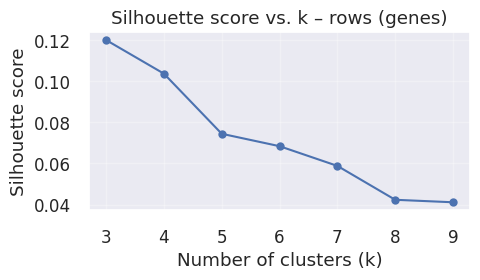

[INFO] Using all 23 samples for silhouette estimation (columns (timepoints)).
k =  3 -> silhouette = 0.163 (columns (timepoints))
k =  4 -> silhouette = 0.171 (columns (timepoints))
k =  5 -> silhouette = 0.171 (columns (timepoints))
k =  6 -> silhouette = 0.153 (columns (timepoints))
k =  7 -> silhouette = 0.193 (columns (timepoints))
k =  8 -> silhouette = 0.193 (columns (timepoints))
k =  9 -> silhouette = 0.199 (columns (timepoints))

[INFO] Best k according to silhouette (columns (timepoints)): 9



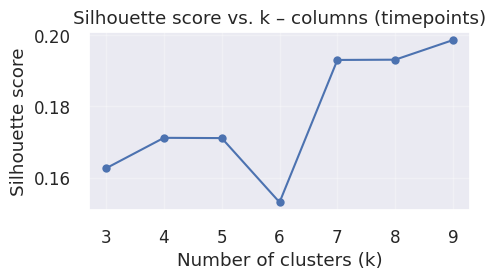

[INFO] Final heuristic choices based on silhouette:
       KR_DEFAULT (row clusters / genes)        = 3
       KC_DEFAULT (column clusters / timepoints) = 9


In [8]:
def estimate_best_k_silhouette(
    X: np.ndarray,
    k_list,
    axis: int = 0,
    linkage: str = "ward",
    max_samples: int = 5000,
    random_state: int = SEED,
    title_suffix: str = "",
):
    """
    Estimate the best number of clusters k using the silhouette score.

    This function can work on:
        - rows (axis=0): genes are rows, timepoints are columns
        - columns (axis=1): timepoints are rows, genes are columns
      by internally transposing X when axis=1.

    Steps:
      1) Optionally subsample rows if n_samples > max_samples (for speed).
      2) For each k in k_list:
             - fit AgglomerativeClustering,
             - compute silhouette score,
             - store the score in a dict.
      3) Return the dictionary {k: silhouette} and the best k (argmax).

    IMPORTANT:
      - Silhouette scores for high-dimensional biological data
        are often small and close to each other.
        We use them only as a heuristic and combine them with
        visual inspection of the heatmaps.

    Parameters
    ----------
    X : np.ndarray, shape (n_genes, n_timepoints)
        Normalized expression matrix (genes × timepoints).
    k_list : list of int
        Candidate values of k to evaluate.
    axis : int, default 0
        If 0: cluster rows (genes). If 1: cluster columns (timepoints).
    linkage : str, default "ward"
        Linkage criterion for AgglomerativeClustering.
        For "ward" the distance metric must be Euclidean.
    max_samples : int, default 5000
        Maximum number of samples used to compute silhouette scores.
        If the number of rows to cluster is larger, we randomly
        subsample max_samples rows (for speed).
    random_state : int
        Seed used for the random subsampling.
    title_suffix : str
        Suffix used in the plot title (e.g. "rows (genes)").

    Returns
    -------
    scores : dict
        Mapping from k (int) to silhouette score (float).
    best_k : int
        Value of k with the highest silhouette score.
    """
    X = np.asarray(X)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got shape {X.shape}")

    if not k_list:
        raise ValueError("k_list must not be empty.")

    # If we want to cluster columns, work on X^T so that samples are rows
    if axis == 1:
        X_work = X.T
    elif axis == 0:
        X_work = X
    else:
        raise ValueError("axis must be 0 (rows) or 1 (columns).")

    n_samples = X_work.shape[0]

    # Optional subsampling for speed
    rng = np.random.RandomState(random_state)
    if n_samples > max_samples:
        sample_idx = rng.choice(n_samples, size=max_samples, replace=False)
        X_eval = X_work[sample_idx]
        print(f"[INFO] Subsampling {max_samples} / {n_samples} samples "
              f"for silhouette estimation ({title_suffix}).")
    else:
        X_eval = X_work
        print(f"[INFO] Using all {n_samples} samples for silhouette estimation "
              f"({title_suffix}).")

    scores = {}
    # For "ward", Euclidean metric is required; for other linkages we also keep Euclidean
    metric = "euclidean"

    for k in k_list:
        # Silhouette requires 2 <= k < n_samples
        if k <= 1 or k >= X_eval.shape[0]:
            print(f"[WARNING] Skipping k={k} for {title_suffix}: "
                  f"invalid for silhouette (needs 2 <= k < n_samples).")
            continue

        model = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage,
            metric=metric,
        )
        labels = model.fit_predict(X_eval)
        score = silhouette_score(X_eval, labels)
        scores[k] = score
        print(f"k = {k:2d} -> silhouette = {score:.3f} ({title_suffix})")

    if not scores:
        raise RuntimeError(f"No valid k values were evaluated for silhouette ({title_suffix}).")

    # Pick the k with the highest silhouette score
    best_k = max(scores, key=scores.get)
    print(f"\n[INFO] Best k according to silhouette ({title_suffix}): {best_k}\n")

    # Quick visualization of silhouette as a function of k
    try:
        ks_sorted = sorted(scores.keys())
        vals_sorted = [scores[k] for k in ks_sorted]

        plt.figure(figsize=(5, 3))
        plt.plot(ks_sorted, vals_sorted, marker="o")
        plt.xlabel("Number of clusters (k)")
        plt.ylabel("Silhouette score")
        plt.title(f"Silhouette score vs. k – {title_suffix}")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        # Plotting is not critical; if it fails, just log a warning
        print(f"[WARNING] Could not plot silhouette curve ({title_suffix}): {e}")

    return scores, best_k


# -------------------------------------------------------------------
# Use the global candidate lists from Cell 1 (if they exist).
# Otherwise, fall back to a reasonable default range.
# -------------------------------------------------------------------
kr_candidates = globals().get("KR_CANDIDATES", [3, 4, 5, 6, 7, 8])
kc_candidates = globals().get("KC_CANDIDATES", [3, 4, 5, 6, 7, 8])

# X must be the normalized & (optionally) variance-filtered matrix
# from the previous preprocessing cell (genes × timepoints).

# 1) Estimate best number of row clusters (genes)
scores_kr, best_kr = estimate_best_k_silhouette(
    X,
    kr_candidates,
    axis=0,
    linkage="ward",
    max_samples=5000,
    random_state=SEED,
    title_suffix="rows (genes)",
)

# 2) Estimate best number of column clusters (timepoints)
scores_kc, best_kc = estimate_best_k_silhouette(
    X,
    kc_candidates,
    axis=1,  # columns
    linkage="ward",
    max_samples=5000,
    random_state=SEED,
    title_suffix="columns (timepoints)",
)

# -------------------------------------------------------------------
# Update the global defaults so that later cells (Model 1 & 2)
# automatically use these data-driven choices.
# -------------------------------------------------------------------
KR_DEFAULT = best_kr
KC_DEFAULT = best_kc

print("[INFO] Final heuristic choices based on silhouette:")
print(f"       KR_DEFAULT (row clusters / genes)        = {KR_DEFAULT}")
print(f"       KC_DEFAULT (column clusters / timepoints) = {KC_DEFAULT}")


Cell 8: Choose kr, kc and plot original heatmap

[INFO] Final choice for Model 1: kr = 3 row clusters, kc = 9 column clusters.
[INFO] Silhouette-based suggestion: kr ≈ 3
[INFO] Plotting full normalized matrix: 3504 genes x 23 timepoints.


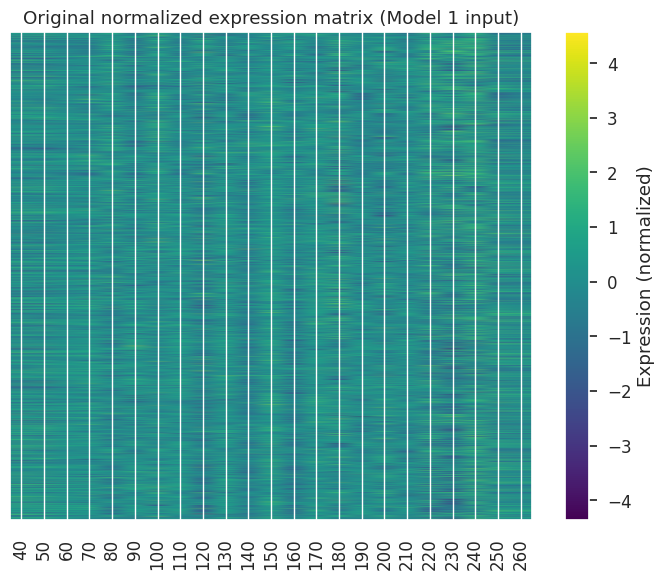

In [9]:
# -------------------------------------------------------------------
# Choose the number of row/column clusters for Model 1.
#
# - best_kr was obtained heuristically in Cell 7 using the silhouette score.
# - KR_DEFAULT and KC_DEFAULT were defined in Cell 1 as "final" choices
#   for the clustering pipeline (for interpretability and report clarity).
#
# In the report we can state:
#   "We first probed kr in {k_candidates} using the silhouette score
#    and obtained best_kr = ... as the suggested value. We then fixed
#    (kr, kc) = (KR_DEFAULT, KC_DEFAULT), which provides a good trade-off
#    between cluster granularity and interpretability of the heatmaps."
# -------------------------------------------------------------------
if "KR_DEFAULT" in globals():
    kr = KR_DEFAULT
else:
    kr = 6  # fallback if Cell 1 was not run as expected

if "KC_DEFAULT" in globals():
    kc = KC_DEFAULT
else:
    kc = 4  # fallback if Cell 1 was not run as expected

print(f"[INFO] Final choice for Model 1: kr = {kr} row clusters, kc = {kc} column clusters.")

# If silhouette-based best_kr is available, print it for reference
if "best_kr" in globals():
    print(f"[INFO] Silhouette-based suggestion: kr ≈ {best_kr}")
else:
    print("[INFO] Silhouette-based kr was not computed (no 'best_kr' in globals).")

# -------------------------------------------------------------------
# Heatmap of the full normalized matrix (Model 1 input)
#
# This figure shows the original normalized gene expression matrix
# (z-scored per gene, and optionally filtered for low-variance genes)
# before any biclustering. With thousands of genes the plot mainly serves
# as a global overview of the data distribution rather than a detailed
# view of individual genes.
# -------------------------------------------------------------------
n_genes, n_timepoints = X.shape
print(f"[INFO] Plotting full normalized matrix: {n_genes} genes x {n_timepoints} timepoints.")

# Sanity check: timepoints length should match the number of columns in X
if "timepoints" in globals() and len(timepoints) != n_timepoints:
    print(f"[WARNING] len(timepoints) = {len(timepoints)} does not match X.shape[1] = {n_timepoints}.")
    x_labels = None
else:
    x_labels = timepoints

plot_heatmap(
    X,
    title="Original normalized expression matrix (Model 1 input)",
    x_ticklabels=x_labels,
    y_ticklabels=None,   # omit gene labels (too many)
    figsize=(7, 6)
)


Cell 9: Part 1 – Hierarchical biclustering on raw (normalized) data

[INFO] Hierarchical biclustering (Model 1) completed.
       Unique row clusters (genes):   [0 1 2]
       Unique column clusters (time): [0 1 2 3 4 5 6 7 8]


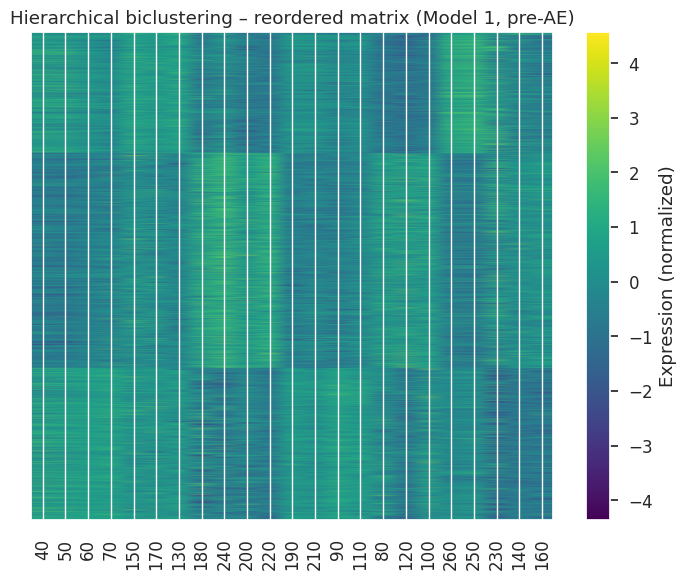

Hierarchical biclustering (Model 1, raw/preprocessed data) – first few biclusters:


,row_cluster,col_cluster,n_rows,n_cols,msr,var
0,0,0,875,4,0.199665,0.676036
1,0,1,875,3,0.241711,0.445049
2,0,2,875,2,0.252888,0.962150
3,0,3,875,2,0.256256,0.719332
4,0,4,875,4,0.222573,0.670300



[Summary] Hierarchical (raw) biclusters:
  Number of biclusters: 27
  MSR  -> min: 0.0000, median: 0.2417, max: 0.5032
  Var  -> min: 0.4450, median: 0.7164, max: 1.7666


In [10]:
# -------------------------------------------------------------------
# 1) Run hierarchical biclustering on the normalized matrix X.
#
# We cluster rows (genes) and columns (time points) separately using
# AgglomerativeClustering with Ward linkage (Euclidean distance).
#
# This corresponds to "Model 1" in the homework:
#   - input: preprocessed + normalized (and optionally filtered) data
#   - method: hierarchical biclustering by separate row/column clustering
# -------------------------------------------------------------------
row_labels_hier, col_labels_hier, row_order_hier, col_order_hier, X_hier_reordered = \
    run_hierarchical_biclustering(X, kr=kr, kc=kc, linkage="ward")

print("[INFO] Hierarchical biclustering (Model 1) completed.")
print(f"       Unique row clusters (genes):   {np.unique(row_labels_hier)}")
print(f"       Unique column clusters (time): {np.unique(col_labels_hier)}")

# -------------------------------------------------------------------
# 2) Plot the reordered matrix.
#
# Rows and columns are ordered by their assigned cluster labels, so
# coherent biclusters should appear as approximately rectangular blocks.
# This heatmap is one of the required visualizations in Part 1.
# -------------------------------------------------------------------
# Make sure timepoints length matches the number of columns for labeling
if "timepoints" in globals() and len(timepoints) == X.shape[1]:
    x_labels_hier = timepoints[col_order_hier]
else:
    x_labels_hier = None
    print("[WARNING] Could not align timepoints with columns for hierarchical heatmap labels.")

plot_heatmap(
    X_hier_reordered,
    title="Hierarchical biclustering – reordered matrix (Model 1, pre-AE)",
    x_ticklabels=x_labels_hier,
    y_ticklabels=None,   # too many genes to label individually
    figsize=(7, 6)
)

# -------------------------------------------------------------------
# 3) Evaluate all kr * kc biclusters using MSR and variance.
#
# Each bicluster corresponds to one (row_cluster, col_cluster) pair.
# We will later:
#   - define a global MSR threshold,
#   - count how many biclusters are "valid",
#   - compare these numbers before and after AE denoising.
# -------------------------------------------------------------------
res_hier_raw = evaluate_biclusters(X, row_labels_hier, col_labels_hier, kr, kc)

print("Hierarchical biclustering (Model 1, raw/preprocessed data) – first few biclusters:")
display(res_hier_raw.head())

# Optional: summary statistics for MSR/variance distributions
print("\n[Summary] Hierarchical (raw) biclusters:")
print("  Number of biclusters:", len(res_hier_raw))
print("  MSR  -> min: {:.4f}, median: {:.4f}, max: {:.4f}".format(
    res_hier_raw["msr"].min(),
    res_hier_raw["msr"].median(),
    res_hier_raw["msr"].max()
))
print("  Var  -> min: {:.4f}, median: {:.4f}, max: {:.4f}".format(
    res_hier_raw["var"].min(),
    res_hier_raw["var"].median(),
    res_hier_raw["var"].max()
))


Cell 10: Part 1 – Spectral biclustering on raw (normalized) data

[INFO] Spectral Biclustering (Model 1) completed.
       Unique row clusters (genes):   [0 1 2]
       Unique column clusters (time): [0 1 2 3 4 5 6 7 8]


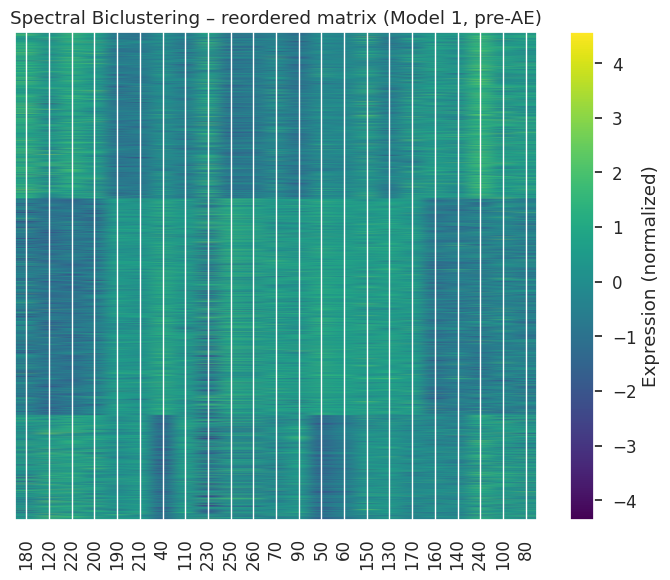

Spectral Biclustering (Model 1, raw/preprocessed data) – first few biclusters:


,row_cluster,col_cluster,n_rows,n_cols,msr,var
0,0,0,1200,4,0.537955,0.843456
1,0,1,1200,4,0.412046,0.589483
2,0,2,1200,1,0.000000,1.196019
3,0,3,1200,2,0.051244,0.626175
4,0,4,1200,4,0.305769,0.628375



[Summary] Spectral (raw) biclusters:
  Number of biclusters: 27
  MSR  -> min: 0.0000, median: 0.2356, max: 0.6714
  Var  -> min: 0.4741, median: 0.7615, max: 2.0161


In [11]:
# -------------------------------------------------------------------
# 1) Run Spectral Biclustering on the same normalized matrix X.
#
# We use scikit-learn's SpectralBiclustering with:
#   - n_clusters = (kr, kc)
#   - method = "bistochastic", which is appropriate for real-valued
#     (possibly negative) normalized expression data.
#
# This provides an alternative biclustering model to compare against
# the hierarchical approach from Cell 9 (same (kr, kc), different method).
# -------------------------------------------------------------------
row_labels_spec, col_labels_spec, row_order_spec, col_order_spec, X_spec_reordered = \
    run_spectral_biclustering(
        X,
        kr=kr,
        kc=kc,
        method="bistochastic",   # explicitly state the chosen method
        random_state=SEED
    )

print("[INFO] Spectral Biclustering (Model 1) completed.")
print(f"       Unique row clusters (genes):   {np.unique(row_labels_spec)}")
print(f"       Unique column clusters (time): {np.unique(col_labels_spec)}")

# -------------------------------------------------------------------
# 2) Plot the reordered matrix for Spectral Biclustering.
#
# As before, rows and columns are ordered by their bicluster assignments.
# This heatmap will be visually compared with the hierarchical one to see
# whether the two methods discover similar or different block structures.
# -------------------------------------------------------------------
if "timepoints" in globals() and len(timepoints) == X.shape[1]:
    x_labels_spec = timepoints[col_order_spec]
else:
    x_labels_spec = None
    print("[WARNING] Could not align timepoints with columns for spectral heatmap labels.")

plot_heatmap(
    X_spec_reordered,
    title="Spectral Biclustering – reordered matrix (Model 1, pre-AE)",
    x_ticklabels=x_labels_spec,
    y_ticklabels=None,
    figsize=(7, 6)
)

# -------------------------------------------------------------------
# 3) Evaluate all kr * kc biclusters using MSR and variance for the
#    Spectral Biclustering solution.
#
# The resulting DataFrame (res_spec_raw) is directly comparable to
# res_hier_raw from Cell 9. Later, we will:
#   - define a global MSR threshold based on both,
#   - count "valid" biclusters,
#   - compare raw vs. AE-denoised data.
# -------------------------------------------------------------------
res_spec_raw = evaluate_biclusters(X, row_labels_spec, col_labels_spec, kr, kc)

print("Spectral Biclustering (Model 1, raw/preprocessed data) – first few biclusters:")
display(res_spec_raw.head())

# Optional: small summary of MSR/variance distributions for comparison
print("\n[Summary] Spectral (raw) biclusters:")
print("  Number of biclusters:", len(res_spec_raw))
print("  MSR  -> min: {:.4f}, median: {:.4f}, max: {:.4f}".format(
    res_spec_raw["msr"].min(),
    res_spec_raw["msr"].median(),
    res_spec_raw["msr"].max()
))
print("  Var  -> min: {:.4f}, median: {:.4f}, max: {:.4f}".format(
    res_spec_raw["var"].min(),
    res_spec_raw["var"].median(),
    res_spec_raw["var"].max()
))


Cell 11: Define MSR threshold and count valid biclusters (raw data)

In [12]:
# -------------------------------------------------------------------
# Strategy:
#   We define a *global* MSR threshold across both biclustering methods
#   (hierarchical and spectral) on the preprocessed raw data (Model 1).
#
#   Specifically, we take the p-th percentile (here p = 30%) of the
#   combined MSR distribution. Biclusters with MSR <= threshold
#   are considered "valid".
#
#   This provides a *relative* notion of quality that is comparable
#   between methods, and we will reuse the same threshold later when
#   we evaluate biclusters on AE-denoised data (Model 2).
# -------------------------------------------------------------------

# Use globally configured MSR_PERCENTILE if available, otherwise default to 0.30
if "MSR_PERCENTILE" not in globals():
    MSR_PERCENTILE = 0.30  # 30% best biclusters (lowest MSR) labeled as valid

# Concatenate MSR values from both methods (Model 1, raw data)
all_msr_raw = np.concatenate([
    res_hier_raw["msr"].values,
    res_spec_raw["msr"].values
])

# Remove NaNs (in case some biclusters were empty or invalid)
all_msr_raw_clean = all_msr_raw[~np.isnan(all_msr_raw)]

if all_msr_raw_clean.size == 0:
    raise RuntimeError("All MSR values are NaN; cannot define a global MSR threshold.")

# Compute the global MSR threshold at the chosen percentile
msr_threshold = np.quantile(all_msr_raw_clean, MSR_PERCENTILE)

print(
    f"Global MSR threshold (percentile {MSR_PERCENTILE*100:.0f}% "
    f"of combined hierarchical + spectral MSR): {msr_threshold:.4f}"
)

# Optional: small diagnostic on MSR distribution (useful for report text)
print("\n[Diagnostic] Combined MSR distribution (Model 1, both methods):")
print("  min   :", float(all_msr_raw_clean.min()))
print("  median:", float(np.median(all_msr_raw_clean)))
print("  max   :", float(all_msr_raw_clean.max()))

# -------------------------------------------------------------------
# Mark valid biclusters based on this threshold for both methods.
# -------------------------------------------------------------------
for df_res in (res_hier_raw, res_spec_raw):
    df_res["valid"] = df_res["msr"] <= msr_threshold

valid_hier_raw = res_hier_raw[res_hier_raw["valid"]]
valid_spec_raw = res_spec_raw[res_spec_raw["valid"]]

# -------------------------------------------------------------------
# Print summary statistics for Model 1 (raw data).
# These numbers will later be compared with the AE-denoised model (Model 2).
# -------------------------------------------------------------------
print("\n=== Raw data summary (Model 1) ===")
print(f"Hierarchical: total={len(res_hier_raw)}, valid={len(valid_hier_raw)}")
print(f"Spectral    : total={len(res_spec_raw)}, valid={len(valid_spec_raw)}")
print(f"Hierarchical – mean MSR (valid): {valid_hier_raw['msr'].mean():.4f}")
print(f"Spectral     – mean MSR (valid): {valid_spec_raw['msr'].mean():.4f}")
print(f"Hierarchical – mean Var (valid): {valid_hier_raw['var'].mean():.4f}")
print(f"Spectral     – mean Var (valid): {valid_spec_raw['var'].mean():.4f}")

# -------------------------------------------------------------------
# Build a compact summary DataFrame for Model 1 (raw data),
# which we will later merge with the AE-denoised model (Model 2).
# -------------------------------------------------------------------
summary_raw = pd.DataFrame([
    {
        "model": "raw_hierarchical",
        "total_biclusters": len(res_hier_raw),
        "valid_biclusters": len(valid_hier_raw),
        "mean_msr_valid": valid_hier_raw["msr"].mean(),
        "mean_var_valid": valid_hier_raw["var"].mean(),
    },
    {
        "model": "raw_spectral",
        "total_biclusters": len(res_spec_raw),
        "valid_biclusters": len(valid_spec_raw),
        "mean_msr_valid": valid_spec_raw["msr"].mean(),
        "mean_var_valid": valid_spec_raw["var"].mean(),
    },
])

print("\nCompact summary for Model 1 (raw data):")
display(summary_raw)


Global MSR threshold (percentile 35% of combined hierarchical + spectral MSR): 0.2031

[Diagnostic] Combined MSR distribution (Model 1, both methods):
  min   : 0.0
  median: 0.23867367208003998
  max   : 0.6713950634002686

=== Raw data summary (Model 1) ===
Hierarchical: total=27, valid=8
Spectral    : total=27, valid=11
Hierarchical – mean MSR (valid): 0.0570
Spectral     – mean MSR (valid): 0.0452
Hierarchical – mean Var (valid): 1.0330
Spectral     – mean Var (valid): 1.0294

Compact summary for Model 1 (raw data):


,model,total_biclusters,valid_biclusters,mean_msr_valid,mean_var_valid
0,raw_hierarchical,27,8,0.056983,1.032983
1,raw_spectral,27,11,0.045177,1.029376


Cell 12: Plot top 5 biclusters (raw data)

[INFO] Plotting top 5 hierarchical biclusters (Model 1, raw).


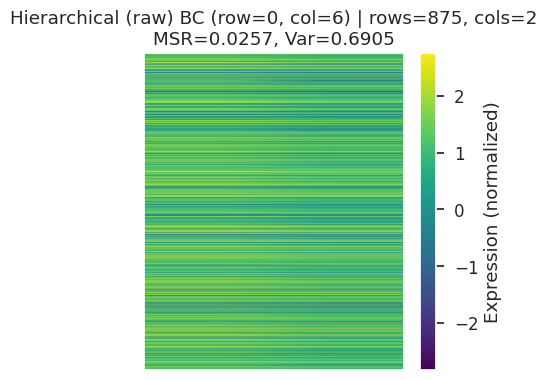

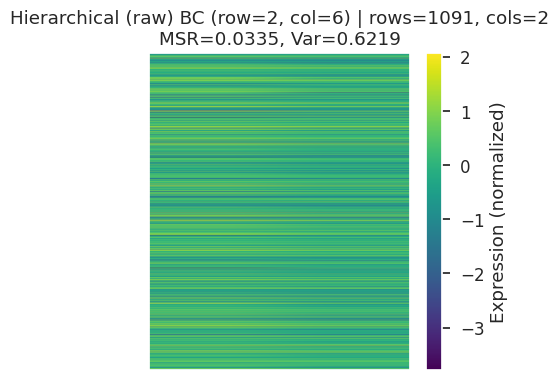

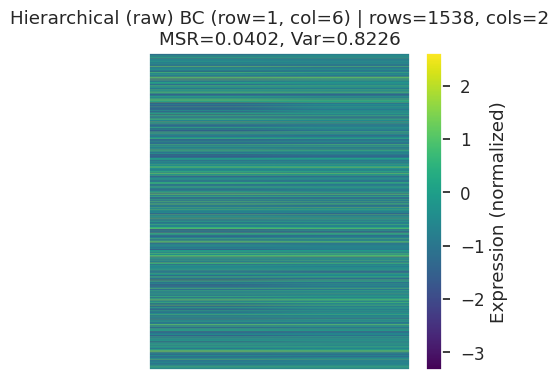

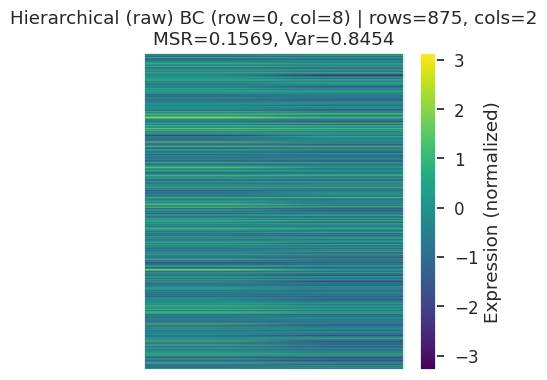

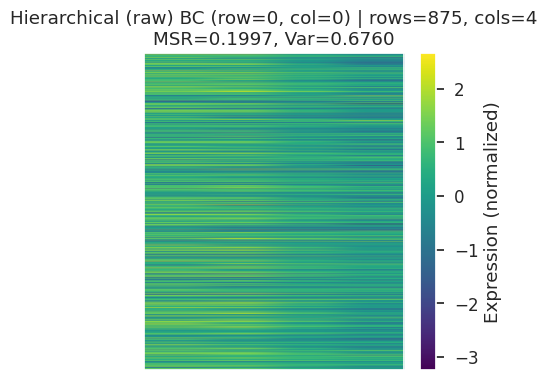

[INFO] Plotting top 5 spectral biclusters (Model 1, raw).


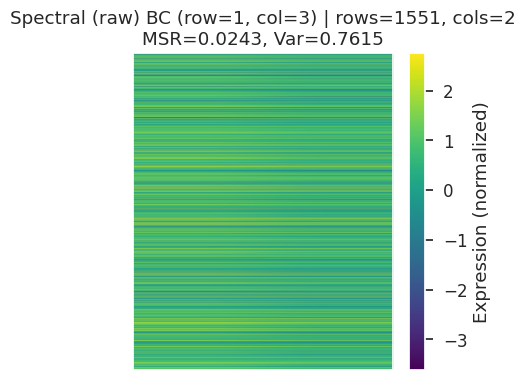

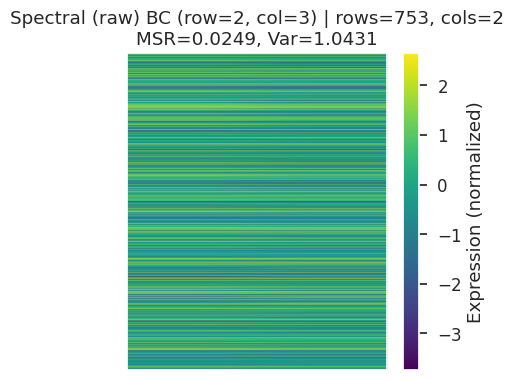

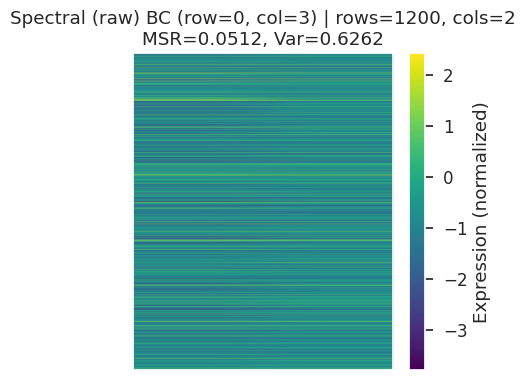

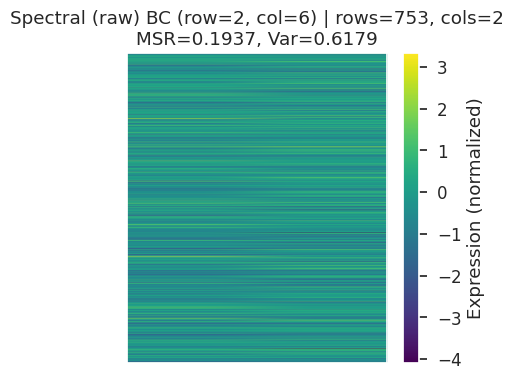

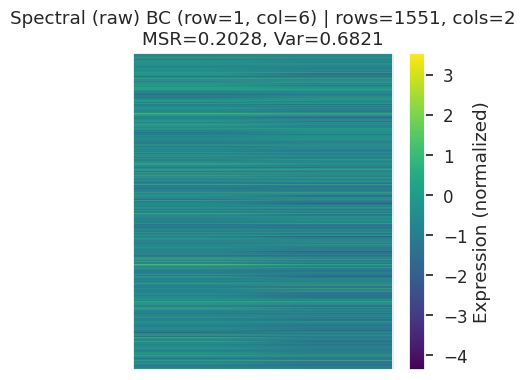

In [13]:
# -------------------------------------------------------------------
# Here we visualize the "best" biclusters (lowest MSR) found on the
# preprocessed raw data (Model 1).
#
# IMPORTANT:
#   In plot_top_biclusters we explicitly require at least 2 columns
#   (min_cols = 2). This avoids trivial 1-column biclusters that have
#   MSR = 0 by construction but are usually less informative for
#   temporal pattern analysis.
#
# We plot:
#   - top 5 hierarchical biclusters
#   - top 5 spectral biclusters
#
# These figures are directly usable in the report to illustrate
# the structure of representative biclusters in Model 1.
# -------------------------------------------------------------------

TOP_N_BICLUSTERS = 5  # number of biclusters to visualize per method

print(f"[INFO] Plotting top {TOP_N_BICLUSTERS} hierarchical biclusters (Model 1, raw).")

# Top 5 hierarchical biclusters on raw data
plot_top_biclusters(
    X=X,
    row_labels=row_labels_hier,
    col_labels=col_labels_hier,
    results_df=res_hier_raw,
    top_n=TOP_N_BICLUSTERS,
    title_prefix="Hierarchical (raw)",
    min_rows=1,
    min_cols=2  # require at least 2 timepoints in a bicluster
)

print(f"[INFO] Plotting top {TOP_N_BICLUSTERS} spectral biclusters (Model 1, raw).")

# Top 5 spectral biclusters on raw data
plot_top_biclusters(
    X=X,
    row_labels=row_labels_spec,
    col_labels=col_labels_spec,
    results_df=res_spec_raw,
    top_n=TOP_N_BICLUSTERS,
    title_prefix="Spectral (raw)",
    min_rows=1,
    min_cols=2  # require at least 2 timepoints in a bicluster
)


Cell 13: Build Denoising Autoencoder (AE)

In [14]:
def build_denoising_autoencoder(
    input_dim: int,
    latent_dim: int = 6,
    hidden_dim: int = 32,
    noise_std: float = 0.1,
    learning_rate: float = 1e-3,
) -> tf.keras.Model:
    """
    Build a simple feed-forward Denoising Autoencoder using the Keras functional API.

    Architecture (symmetric encoder–decoder):
        input (R^input_dim)
            -> GaussianNoise(noise_std)
            -> Dense(hidden_dim, relu)
            -> Dense(latent_dim, relu)          <-- bottleneck (compressed code)
            -> Dense(hidden_dim, relu)
            -> Dense(input_dim, linear)         <-- reconstruction

    Design choices (for the report):
    --------------------------------
    - input_dim:
        Number of time points per gene (e.g. 23). We treat each gene's
        temporal expression pattern as a vector in R^(#timepoints).

    - latent_dim:
        Size of the bottleneck representation. A smaller latent_dim
        forces stronger compression, which can remove noise but may also
        discard relevant biological signal (underfitting). A larger latent_dim
        allows more detailed reconstruction but risks overfitting and
        weaker denoising. In our configuration we use latent_dim ≈ 6,
        which corresponds to ~4x compression for 23 timepoints and empirically
        provides a good trade-off between denoising and information retention.

    - hidden_dim:
        Width of the hidden layers on each side of the bottleneck.
        hidden_dim = 32 provides moderate capacity: large enough to
        model non-linear temporal patterns, but small enough to avoid
        severe overfitting given a few thousand genes.

    - noise_std:
        Standard deviation of Gaussian noise added to the inputs during
        training. This encourages the network to learn a robust mapping
        from noisy inputs to clean outputs, rather than simply copying
        the input. A value around 0.1 perturbs the row-wise z-scored
        expression values slightly without destroying their overall shape.

    - learning_rate:
        Learning rate for the Adam optimizer. We use 1e-3 as a standard,
        stable value for a network of this size.

    Returns
    -------
    model : tf.keras.Model
        Compiled autoencoder model (input -> reconstruction).
    """
    if input_dim <= 0:
        raise ValueError(f"input_dim must be positive, got {input_dim}.")
    if latent_dim <= 0 or latent_dim >= input_dim:
        print(
            f"[WARNING] Unusual latent_dim={latent_dim} for input_dim={input_dim}. "
            "Typically latent_dim < input_dim and not too small."
        )

    # Input layer (one vector per gene: expression over time points)
    inp = Input(shape=(input_dim,), name="input")

    # Add Gaussian noise for denoising behavior
    x = GaussianNoise(noise_std, name="gaussian_noise")(inp)

    # Encoder part
    h1 = Dense(hidden_dim, activation="relu", name="enc_hidden")(x)
    latent = Dense(latent_dim, activation="relu", name="latent")(h1)

    # Decoder part (mirroring the encoder)
    h2 = Dense(hidden_dim, activation="relu", name="dec_hidden")(latent)
    out = Dense(input_dim, activation="linear", name="recon")(h2)

    # Build and compile the model
    model = Model(inputs=inp, outputs=out, name="denoising_autoencoder")
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")

    return model


# -------------------------------------------------------------------
# Instantiate the AE with chosen hyperparameters
# -------------------------------------------------------------------
# Each row of X is a z-scored time-course for one gene, so:
input_dim = X.shape[1]  # number of time points per gene

# Use global configuration from Cell 1 if available; otherwise fall back to defaults
if "AE_LATENT_DIM" in globals():
    LATENT_DIM = AE_LATENT_DIM
else:
    LATENT_DIM = 6  # ~4x compression for 23 timepoints

if "AE_HIDDEN_DIM" in globals():
    HIDDEN_DIM = AE_HIDDEN_DIM
else:
    HIDDEN_DIM = 32

if "AE_NOISE_STD" in globals():
    NOISE_STD = AE_NOISE_STD
else:
    NOISE_STD = 0.10

if "AE_LR" in globals():
    AE_LR = AE_LR
else:
    AE_LR = 1e-3

print("[INFO] Building Denoising Autoencoder with:")
print(f"       input_dim  = {input_dim}")
print(f"       latent_dim = {LATENT_DIM}")
print(f"       hidden_dim = {HIDDEN_DIM}")
print(f"       noise_std  = {NOISE_STD}")
print(f"       learning_rate = {AE_LR}")

ae = build_denoising_autoencoder(
    input_dim=input_dim,
    latent_dim=LATENT_DIM,
    hidden_dim=HIDDEN_DIM,
    noise_std=NOISE_STD,
    learning_rate=AE_LR,
)

# Print model summary (useful both for debugging and for the report)
ae.summary()


[INFO] Building Denoising Autoencoder with:
       input_dim  = 23
       latent_dim = 3
       hidden_dim = 32
       noise_std  = 0.2
       learning_rate = 0.001


Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 23)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 23)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_hidden (Dense)              │ (None, 32)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 3)              │            99 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_hidden (Dense)              │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ recon (Dense)                   │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,754 (6.85 KB)

 Trainable params: 1,754 (6.85 KB)

 Non-trainable params: 0 (0.00 B)

Cell 14: Train the Denoising Autoencoder

[INFO] AE training configuration:
       epochs        = 300
       batch_size    = 64
       val_split     = 0.1
       early_stop_patience = 15
Epoch 1/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.9874 - val_loss: 0.9154 - learning_rate: 0.0010
Epoch 2/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8689 - val_loss: 0.7927 - learning_rate: 0.0010
Epoch 3/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7516 - val_loss: 0.6961 - learning_rate: 0.0010
Epoch 4/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6734 - val_loss: 0.6107 - learning_rate: 0.0010
Epoch 5/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5923 - val_loss: 0.5097 - learning_rate: 0.0010
Epoch 6/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5103 - val_loss: 0.4696 - learning_rate: 0.0010
Epoch 7/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4786 - val_loss: 0.4552 - learning_rate: 0.0010
Epoch 8/300
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4652 - val_loss: 0.4489 - lea

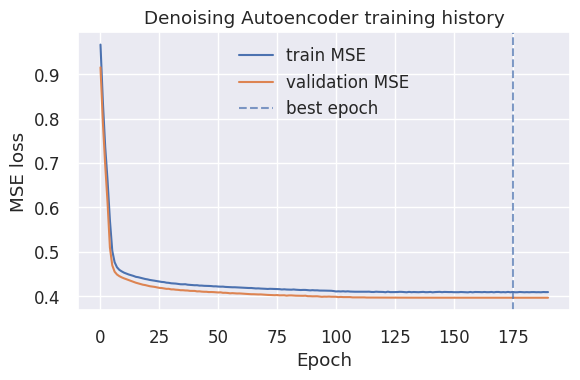

In [15]:
# -------------------------------------------------------------------
# 1) Training hyperparameters
#
# We primarily control training via the global configuration defined
# in Cell 1. If those variables are not present for any reason, we
# fall back to reasonable defaults.
# -------------------------------------------------------------------
if "AE_EPOCHS" in globals():
    EPOCHS = AE_EPOCHS
else:
    EPOCHS = 300

if "AE_BATCH_SIZE" in globals():
    BATCH_SIZE = AE_BATCH_SIZE
else:
    BATCH_SIZE = 64

if "AE_VAL_SPLIT" in globals():
    VAL_SPLIT = AE_VAL_SPLIT
else:
    VAL_SPLIT = 0.10  # 10% of genes used for validation

if "AE_EARLY_STOP_PATIENCE" in globals():
    EARLY_STOP_PATIENCE = AE_EARLY_STOP_PATIENCE
else:
    EARLY_STOP_PATIENCE = 10

print("[INFO] AE training configuration:")
print(f"       epochs        = {EPOCHS}")
print(f"       batch_size    = {BATCH_SIZE}")
print(f"       val_split     = {VAL_SPLIT}")
print(f"       early_stop_patience = {EARLY_STOP_PATIENCE}")

# -------------------------------------------------------------------
# 2) Callbacks: EarlyStopping and (optional) ReduceLROnPlateau
#
# EarlyStopping:
#   - stops training if validation loss does not improve for several epochs,
#   - prevents overfitting to training genes,
#   - restores model weights from the best validation epoch.
#
# ReduceLROnPlateau (optional):
#   - reduces the learning rate when the validation loss plateaus,
#   - can help the optimizer converge to a better minimum.
# -------------------------------------------------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=max(3, EARLY_STOP_PATIENCE // 3),
    min_lr=1e-5,
    verbose=1
)

callbacks = [early_stop, reduce_lr]

# -------------------------------------------------------------------
# 3) Train the AE.
#
# Inputs and targets are both X:
#   - each row of X is a z-scored time-course for one gene,
#   - the AE learns to reconstruct the clean version of this profile
#     from a noisy version (GaussianNoise layer in the model).
#
# We reserve a fraction (VAL_SPLIT) of the genes as a validation set
# to monitor generalization performance.
# -------------------------------------------------------------------
if "ae" not in globals():
    raise RuntimeError("Autoencoder model 'ae' is not defined. Please run Cell 13 first.")

history = ae.fit(
    X, X,                      # Input and target are the same (autoencoder)
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,              # shuffle gene order each epoch
    validation_split=VAL_SPLIT,
    callbacks=callbacks,
    verbose=1
)

# -------------------------------------------------------------------
# 4) Inspect training history: training vs validation MSE over epochs.
#
# We expect:
#   - both curves to decrease over time,
#   - validation loss to roughly follow training loss,
#   - a large, persistent gap would indicate overfitting.
# -------------------------------------------------------------------
train_loss = history.history.get("loss", [])
val_loss = history.history.get("val_loss", [])

if len(val_loss) > 0:
    best_epoch = int(np.argmin(val_loss))
    best_val = float(val_loss[best_epoch])
    print(f"\n[INFO] Best validation loss: {best_val:.4f} at epoch {best_epoch + 1}")
else:
    best_epoch = None
    print("\n[WARNING] No validation loss recorded (check 'validation_split').")

plt.figure(figsize=(6, 4))
plt.plot(train_loss, label="train MSE")
if len(val_loss) > 0:
    plt.plot(val_loss, label="validation MSE")
    plt.axvline(best_epoch, linestyle="--", alpha=0.7, label="best epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Denoising Autoencoder training history")
plt.legend()
plt.tight_layout()
plt.show()


Cell 15: Reconstruct (denoised) matrix and simple comparison

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Denoised matrix shape (genes, timepoints): (3504, 23)

Global reconstruction MSE (averaged over genes): 0.402496
Per-gene MSE summary:
  min  : 0.041000
  25%  : 0.237930
  50%  : 0.370138
  75%  : 0.536105
  max  : 1.292148


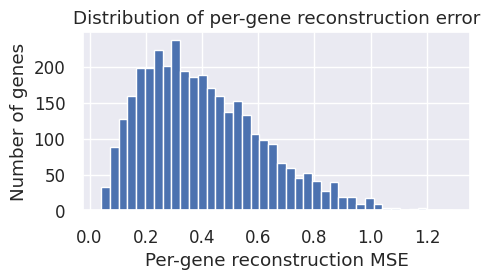

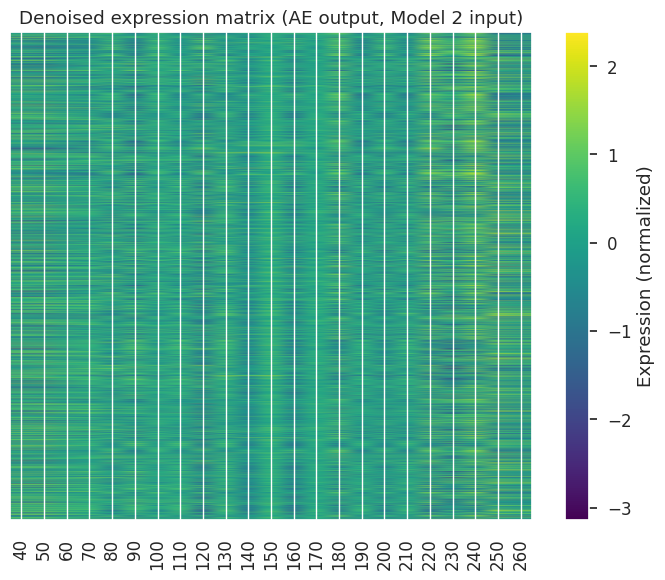


Example gene index for visualization: 2841


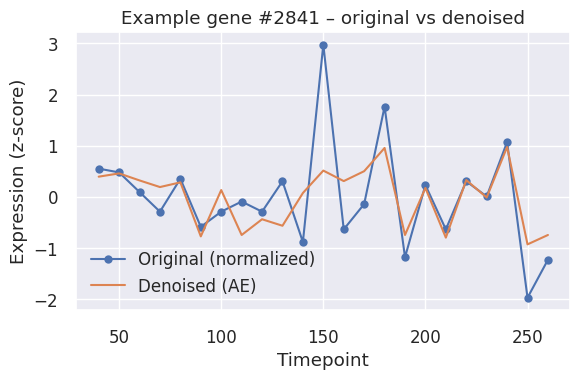

In [16]:
# -------------------------------------------------------------------
# 1) Use the trained AE to reconstruct / denoise the expression matrix.
#
# Each row of X (a gene's z-scored temporal profile) is passed through
# the autoencoder. The output X_denoised has the same shape as X and
# will be used as the input for biclustering in Model 2.
# -------------------------------------------------------------------
if "ae" not in globals():
    raise RuntimeError("Autoencoder model 'ae' not found. Please run Cells 13–14 first.")

if "BATCH_SIZE" not in globals():
    BATCH_SIZE = 64  # reasonable fallback

X_denoised = ae.predict(X, batch_size=BATCH_SIZE)
X_denoised = X_denoised.astype(np.float32)  # keep a compact and consistent dtype

print("Denoised matrix shape (genes, timepoints):", X_denoised.shape)

# Sanity check: ensure same shape as input X
if X_denoised.shape != X.shape:
    raise RuntimeError(
        f"Shape mismatch after denoising: X.shape={X.shape}, "
        f"X_denoised.shape={X_denoised.shape}"
    )

# -------------------------------------------------------------------
# 2) Compute overall reconstruction error (MSE) and per-gene MSE.
#    This quantifies how much the AE has altered the data.
# -------------------------------------------------------------------
mse_per_gene = np.mean((X_denoised - X) ** 2, axis=1)
recon_mse = float(mse_per_gene.mean())

print(f"\nGlobal reconstruction MSE (averaged over genes): {recon_mse:.6f}")
print("Per-gene MSE summary:")
print("  min  : {:.6f}".format(mse_per_gene.min()))
print("  25%  : {:.6f}".format(np.quantile(mse_per_gene, 0.25)))
print("  50%  : {:.6f}".format(np.median(mse_per_gene)))
print("  75%  : {:.6f}".format(np.quantile(mse_per_gene, 0.75)))
print("  max  : {:.6f}".format(mse_per_gene.max()))

# Optional: visualize MSE distribution across genes
plt.figure(figsize=(5, 3))
plt.hist(mse_per_gene, bins=40)
plt.xlabel("Per-gene reconstruction MSE")
plt.ylabel("Number of genes")
plt.title("Distribution of per-gene reconstruction error")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 3) Plot heatmap of the denoised matrix.
#
# This is the "Model 2" input for biclustering (same shape as X, but
# with smoothed profiles). Comparing this heatmap with the one from
# the original normalized matrix shows how aggressively the AE has
# smoothed the data.
# -------------------------------------------------------------------
if "timepoints" in globals() and len(timepoints) == X_denoised.shape[1]:
    x_labels_den = timepoints
else:
    x_labels_den = None
    print("[WARNING] Could not align timepoints with columns for denoised heatmap labels.")

plot_heatmap(
    X_denoised,
    title="Denoised expression matrix (AE output, Model 2 input)",
    x_ticklabels=x_labels_den,
    y_ticklabels=None,
    figsize=(7, 6)
)

# -------------------------------------------------------------------
# 4) Additionally, compare one example gene's time-course before vs
#    after denoising. This gives an intuitive view of what the AE does:
#    ideally it smooths noisy fluctuations while preserving the main
#    temporal pattern.
# -------------------------------------------------------------------
# For reproducibility, we can either fix the index or sample randomly.
# Here we use a random gene but also print its index.
gene_idx = np.random.randint(0, X.shape[0])
print(f"\nExample gene index for visualization: {gene_idx}")

# Convert timepoints to something plottable on x-axis (strings are fine, but
# we can also convert to numeric for nicer spacing)
try:
    x_axis = timepoints.astype(float)
except Exception:
    x_axis = timepoints  # fall back to string labels if conversion fails

plt.figure(figsize=(6, 4))
plt.plot(x_axis, X[gene_idx, :], marker="o", label="Original (normalized)")
plt.plot(x_axis, X_denoised[gene_idx, :], marker="x", label="Denoised (AE)")
plt.xlabel("Timepoint")
plt.ylabel("Expression (z-score)")
plt.title(f"Example gene #{gene_idx} – original vs denoised")
plt.legend()
plt.tight_layout()
plt.show()


Cell 16: Part 2 – Hierarchical biclustering on AE-denoised data

[INFO] Hierarchical biclustering (Model 2, AE-denoised) completed.
       Unique row clusters (genes):   [0 1 2]
       Unique column clusters (time): [0 1 2 3 4 5 6 7 8]


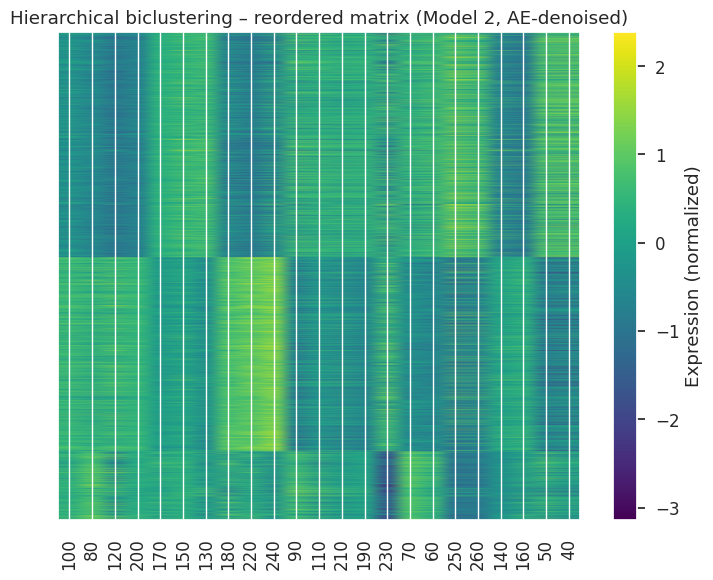

Hierarchical biclustering (AE-denoised data, Model 2) – first few biclusters:


,row_cluster,col_cluster,n_rows,n_cols,msr,var
0,0,0,1620,4,0.071443,0.197181
1,0,1,1620,3,0.052578,0.132821
2,0,2,1620,3,0.042646,0.390444
3,0,3,1620,4,0.042386,0.321356
4,0,4,1620,1,0.000000,0.698166



[Summary] Hierarchical (denoised) biclusters:
  Number of biclusters: 27
  MSR  -> min: 0.0000, median: 0.0233, max: 0.1287
  Var  -> min: 0.1328, median: 0.3253, max: 0.6982


In [17]:
# -------------------------------------------------------------------
# 1) Run hierarchical biclustering on the AE-denoised matrix X_denoised.
#
# This mirrors Cell 9 (Model 1), but now the input is the smoothed /
# denoised expression matrix produced by the autoencoder (Model 2).
#
# We deliberately keep the same (kr, kc) as before to ensure a *fair*
# comparison with the biclustering results on the raw preprocessed data:
#   - same number of gene clusters
#   - same number of timepoint clusters
# -------------------------------------------------------------------
if "X_denoised" not in globals():
    raise RuntimeError("X_denoised is not defined. Please run Cells 13–15 first.")

row_labels_hier_d, col_labels_hier_d, row_order_hier_d, col_order_hier_d, X_hier_d_reordered = \
    run_hierarchical_biclustering(X_denoised, kr=kr, kc=kc, linkage="ward")

print("[INFO] Hierarchical biclustering (Model 2, AE-denoised) completed.")
print(f"       Unique row clusters (genes):   {np.unique(row_labels_hier_d)}")
print(f"       Unique column clusters (time): {np.unique(col_labels_hier_d)}")

# -------------------------------------------------------------------
# 2) Plot the reordered denoised matrix.
#
# Comparing this heatmap to the one from Cell 9 (Model 1, raw/preprocessed)
# provides a visual sense of how AE-denoising affects the bicluster structure
# discovered by hierarchical clustering:
#   - Are blocks more contrasted / cleaner?
#   - Do clusters look more compact?
# -------------------------------------------------------------------
if "timepoints" in globals() and len(timepoints) == X_denoised.shape[1]:
    x_labels_hier_d = timepoints[col_order_hier_d]
else:
    x_labels_hier_d = None
    print("[WARNING] Could not align timepoints with columns for hierarchical (denoised) heatmap labels.")

plot_heatmap(
    X_hier_d_reordered,
    title="Hierarchical biclustering – reordered matrix (Model 2, AE-denoised)",
    x_ticklabels=x_labels_hier_d,
    y_ticklabels=None,
    figsize=(7, 6)
)

# -------------------------------------------------------------------
# 3) Evaluate all kr * kc biclusters (on the denoised data) using MSR
#    and variance, analogous to what we did for Model 1.
#
# The resulting DataFrame (res_hier_den) will later be used to:
#   - count valid biclusters under the same global MSR threshold,
#   - compare mean MSR/variance between Model 1 and Model 2,
#   - answer the analysis questions from the homework.
# -------------------------------------------------------------------
res_hier_den = evaluate_biclusters(X_denoised, row_labels_hier_d, col_labels_hier_d, kr, kc)

print("Hierarchical biclustering (AE-denoised data, Model 2) – first few biclusters:")
display(res_hier_den.head())

# Optional: quick summary of MSR/variance distribution for Model 2
print("\n[Summary] Hierarchical (denoised) biclusters:")
print("  Number of biclusters:", len(res_hier_den))
print("  MSR  -> min: {:.4f}, median: {:.4f}, max: {:.4f}".format(
    res_hier_den["msr"].min(),
    res_hier_den["msr"].median(),
    res_hier_den["msr"].max()
))
print("  Var  -> min: {:.4f}, median: {:.4f}, max: {:.4f}".format(
    res_hier_den["var"].min(),
    res_hier_den["var"].median(),
    res_hier_den["var"].max()
))


Cell 17: Part 2 – Spectral biclustering on AE-denoised data

[INFO] Spectral Biclustering (Model 2, AE-denoised) completed.
       Unique row clusters (genes):   [0 1 2]
       Unique column clusters (time): [0 1 2 3 4 5 6 7 8]


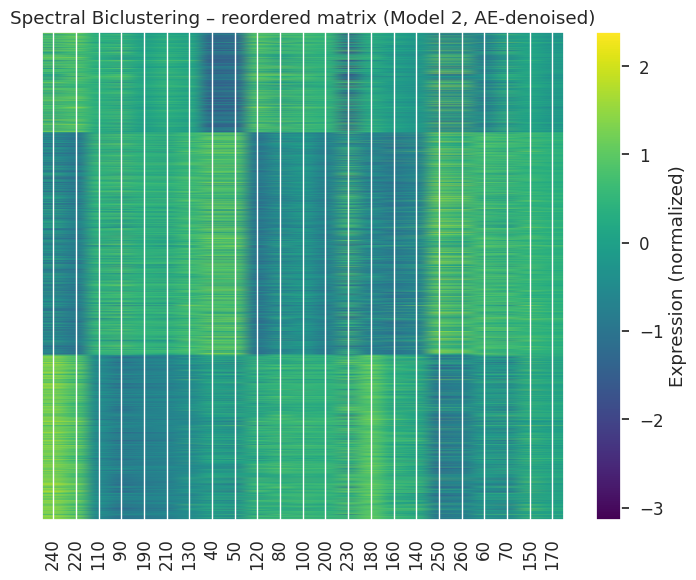

Spectral Biclustering (AE-denoised data, Model 2) – first few biclusters:


,row_cluster,col_cluster,n_rows,n_cols,msr,var
0,0,0,726,2,0.086083,0.393491
1,0,1,726,5,0.060912,0.166332
2,0,2,726,2,0.002993,0.439692
3,0,3,726,4,0.058469,0.310453
4,0,4,726,1,0.000000,1.194966



[Summary] Spectral (denoised) biclusters:
  Number of biclusters: 27
  MSR  -> min: 0.0000, median: 0.0196, max: 0.1032
  Var  -> min: 0.0891, median: 0.2805, max: 1.1950


In [18]:
# -------------------------------------------------------------------
# 1) Run Spectral Biclustering on the AE-denoised matrix X_denoised.
#
# This mirrors Cell 10 (Model 1), but now the input is the denoised
# expression matrix produced by the autoencoder (Model 2).
#
# We keep:
#   - the same (kr, kc),
#   - the same SpectralBiclustering method ("bistochastic"),
# in order to ensure a fair comparison with the raw/preprocessed data.
# -------------------------------------------------------------------
if "X_denoised" not in globals():
    raise RuntimeError("X_denoised is not defined. Please run Cells 13–15 first.")

row_labels_spec_d, col_labels_spec_d, row_order_spec_d, col_order_spec_d, X_spec_d_reordered = \
    run_spectral_biclustering(
        X_denoised,
        kr=kr,
        kc=kc,
        method="bistochastic",   # consistent with Model 1
        random_state=SEED
    )

print("[INFO] Spectral Biclustering (Model 2, AE-denoised) completed.")
print(f"       Unique row clusters (genes):   {np.unique(row_labels_spec_d)}")
print(f"       Unique column clusters (time): {np.unique(col_labels_spec_d)}")

# -------------------------------------------------------------------
# 2) Plot the reordered denoised matrix for Spectral Biclustering.
#
# Comparing this figure to the one from Cell 10 (Model 1, raw data)
# shows how AE-denoising modifies the bicluster structure discovered
# by the spectral method:
#   - Are blocks sharper / smoother?
#   - Do timepoint clusters change?
# -------------------------------------------------------------------
if "timepoints" in globals() and len(timepoints) == X_denoised.shape[1]:
    x_labels_spec_d = timepoints[col_order_spec_d]
else:
    x_labels_spec_d = None
    print("[WARNING] Could not align timepoints with columns for spectral (denoised) heatmap labels.")

plot_heatmap(
    X_spec_d_reordered,
    title="Spectral Biclustering – reordered matrix (Model 2, AE-denoised)",
    x_ticklabels=x_labels_spec_d,
    y_ticklabels=None,
    figsize=(7, 6)
)

# -------------------------------------------------------------------
# 3) Evaluate all kr * kc biclusters (on the denoised data) using MSR
#    and variance, analogous to what we did for Model 1.
#
# The resulting DataFrame (res_spec_den) is directly comparable to
# res_spec_raw from Cell 10, and will be combined with res_hier_den
# to answer the final analysis questions.
# -------------------------------------------------------------------
res_spec_den = evaluate_biclusters(X_denoised, row_labels_spec_d, col_labels_spec_d, kr, kc)

print("Spectral Biclustering (AE-denoised data, Model 2) – first few biclusters:")
display(res_spec_den.head())

# Optional: quick summary of MSR/variance distribution for Model 2
print("\n[Summary] Spectral (denoised) biclusters:")
print("  Number of biclusters:", len(res_spec_den))
print("  MSR  -> min: {:.4f}, median: {:.4f}, max: {:.4f}".format(
    res_spec_den["msr"].min(),
    res_spec_den["msr"].median(),
    res_spec_den["msr"].max()
))
print("  Var  -> min: {:.4f}, median: {:.4f}, max: {:.4f}".format(
    res_spec_den["var"].min(),
    res_spec_den["var"].median(),
    res_spec_den["var"].max()
))


Cell 18: Apply same MSR threshold to denoised data and compare

In [19]:
# -------------------------------------------------------------------
# 1) Mark valid biclusters in Model 2 using the *same* MSR threshold.
#
# We reuse the global threshold msr_threshold that was computed in
# Cell 11 from the combined hierarchical + spectral MSR distribution
# on the raw data (Model 1).
#
# This ensures that "valid" has the same meaning for both models,
# so comparisons between Model 1 and Model 2 are fair.
# -------------------------------------------------------------------
if "msr_threshold" not in globals():
    raise RuntimeError(
        "Global MSR threshold 'msr_threshold' is not defined. "
        "Please run Cell 11 (Model 1 MSR threshold) first."
    )

for df_res in (res_hier_den, res_spec_den):
    df_res["valid"] = df_res["msr"] <= msr_threshold

valid_hier_den = res_hier_den[res_hier_den["valid"]]
valid_spec_den = res_spec_den[res_spec_den["valid"]]

# -------------------------------------------------------------------
# 2) Print summary statistics for Model 2 (denoised data).
#
# These will be contrasted with the Model 1 summary printed in Cell 11
# to answer:
#   1) Did AE-denoising increase or reduce the number of valid biclusters?
#   2) Did MSR improve after denoising?
#   3) How do the reordered heatmaps compare?
# -------------------------------------------------------------------
print("=== Denoised data summary (Model 2) ===")
print(f"Hierarchical: total={len(res_hier_den)}, valid={len(valid_hier_den)}")
print(f"Spectral    : total={len(res_spec_den)}, valid={len(valid_spec_den)}")
print(f"Hierarchical – mean MSR (valid): {valid_hier_den['msr'].mean():.4f}")
print(f"Spectral     – mean MSR (valid): {valid_spec_den['msr'].mean():.4f}")
print(f"Hierarchical – mean Var (valid): {valid_hier_den['var'].mean():.4f}")
print(f"Spectral     – mean Var (valid): {valid_spec_den['var'].mean():.4f}")

# -------------------------------------------------------------------
# 3) Build a compact summary DataFrame for Model 2 (denoised),
#    which we will later merge with summary_raw (Model 1) to create
#    a final comparison table.
# -------------------------------------------------------------------
summary_den = pd.DataFrame([
    {
        "model": "denoised_hierarchical",
        "total_biclusters": len(res_hier_den),
        "valid_biclusters": len(valid_hier_den),
        "mean_msr_valid": valid_hier_den["msr"].mean(),
        "mean_var_valid": valid_hier_den["var"].mean(),
    },
    {
        "model": "denoised_spectral",
        "total_biclusters": len(res_spec_den),
        "valid_biclusters": len(valid_spec_den),
        "mean_msr_valid": valid_spec_den["msr"].mean(),
        "mean_var_valid": valid_spec_den["var"].mean(),
    },
])

print("\nCompact summary for Model 2 (AE-denoised data):")
display(summary_den)


=== Denoised data summary (Model 2) ===
Hierarchical: total=27, valid=27
Spectral    : total=27, valid=27
Hierarchical – mean MSR (valid): 0.0347
Spectral     – mean MSR (valid): 0.0342
Hierarchical – mean Var (valid): 0.3417
Spectral     – mean Var (valid): 0.3696

Compact summary for Model 2 (AE-denoised data):


,model,total_biclusters,valid_biclusters,mean_msr_valid,mean_var_valid
0,denoised_hierarchical,27,27,0.034653,0.341662
1,denoised_spectral,27,27,0.034168,0.369608


Cell 19: Plot top 5 biclusters (denoised data)

[INFO] Plotting top 5 hierarchical biclusters (Model 2, denoised).


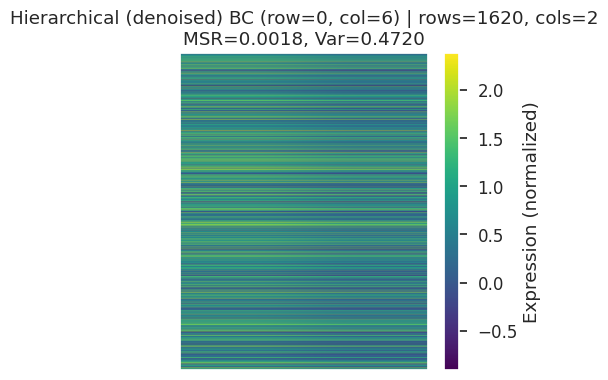

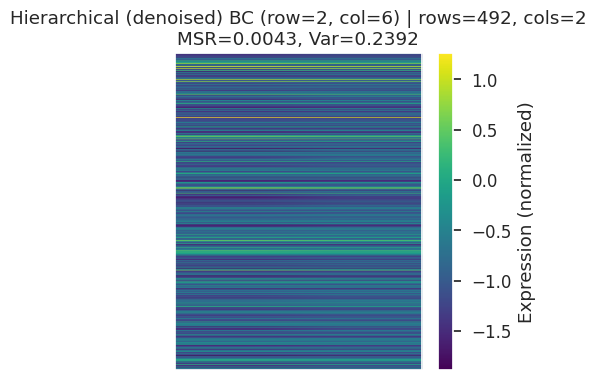

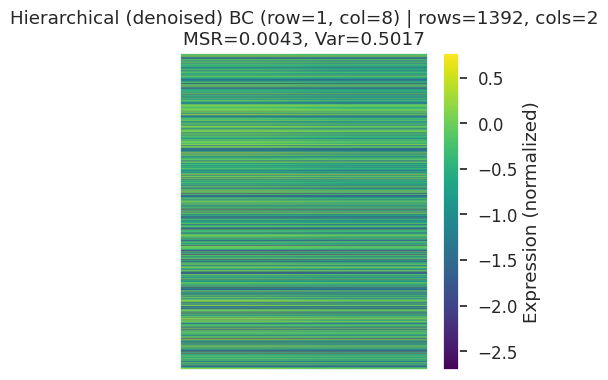

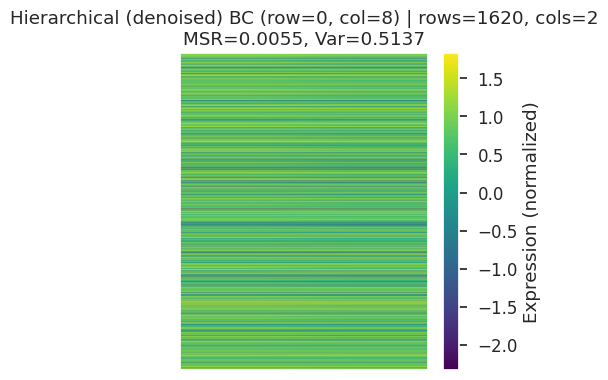

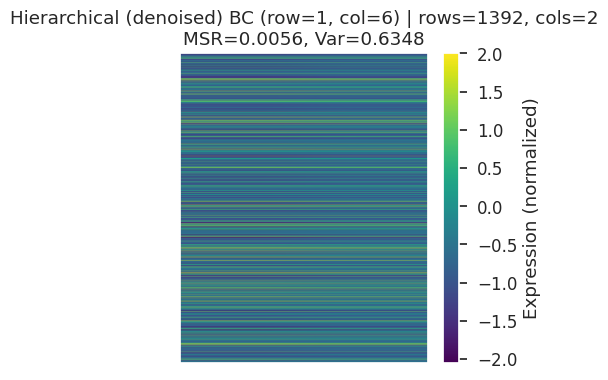

[INFO] Plotting top 5 spectral biclusters (Model 2, denoised).


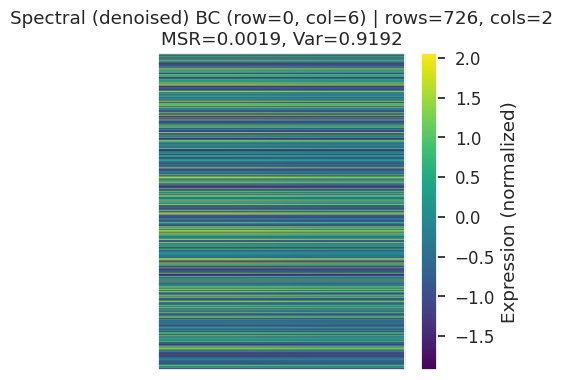

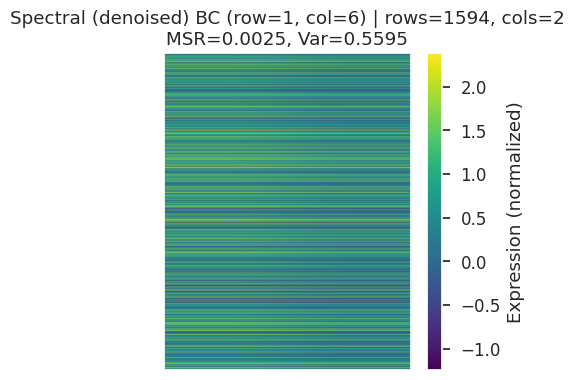

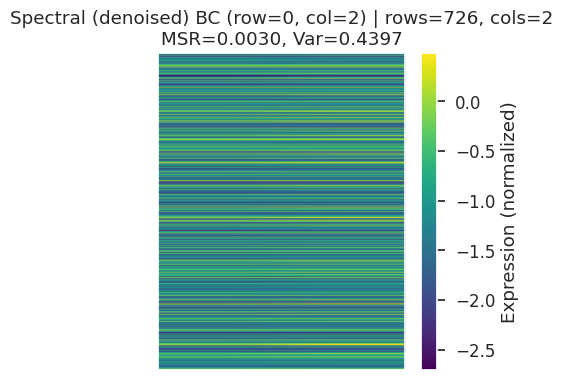

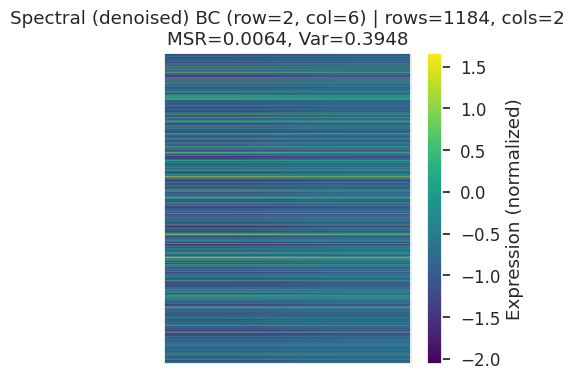

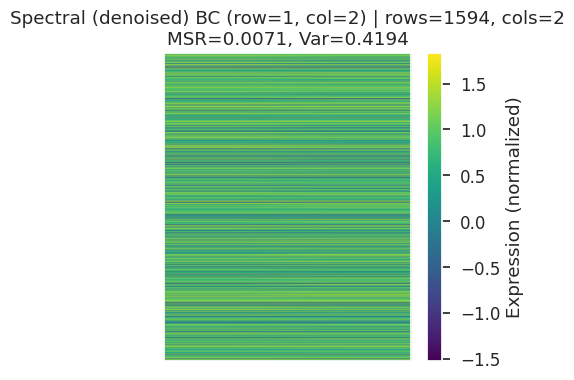

In [20]:
# -------------------------------------------------------------------
# Here we visualize the "best" biclusters (lowest MSR) found on the
# AE-denoised data (Model 2).
#
# As in Cell 12, we require at least 2 columns (time points) in a
# bicluster to avoid trivial 1-column biclusters with MSR = 0.
#
# We plot:
#   - top N hierarchical biclusters (Model 2)
#   - top N spectral biclusters (Model 2)
#
# Comparing these heatmaps with the corresponding ones from Cell 12
# (Model 1, raw data) provides visual evidence of how denoising affects
# the coherence and structure of the identified biclusters.
# -------------------------------------------------------------------

TOP_N_BICLUSTERS_MODEL2 = 5  # number of biclusters to visualize per method

print(f"[INFO] Plotting top {TOP_N_BICLUSTERS_MODEL2} hierarchical biclusters (Model 2, denoised).")

# Top hierarchical biclusters on AE-denoised data
plot_top_biclusters(
    X=X_denoised,
    row_labels=row_labels_hier_d,
    col_labels=col_labels_hier_d,
    results_df=res_hier_den,
    top_n=TOP_N_BICLUSTERS_MODEL2,
    title_prefix="Hierarchical (denoised)",
    min_rows=1,
    min_cols=2  # require at least 2 timepoints per bicluster
)

print(f"[INFO] Plotting top {TOP_N_BICLUSTERS_MODEL2} spectral biclusters (Model 2, denoised).")

# Top spectral biclusters on AE-denoised data
plot_top_biclusters(
    X=X_denoised,
    row_labels=row_labels_spec_d,
    col_labels=col_labels_spec_d,
    results_df=res_spec_den,
    top_n=TOP_N_BICLUSTERS_MODEL2,
    title_prefix="Spectral (denoised)",
    min_rows=1,
    min_cols=2  # require at least 2 timepoints per bicluster
)


 Cell 20: Summary table for the report

In [21]:
# -------------------------------------------------------------------
# Build a combined summary DataFrame that compares:
#   - raw_hierarchical
#   - raw_spectral
#   - denoised_hierarchical
#   - denoised_spectral
#
# For each model we report:
#   - total_biclusters  : total number of biclusters (kr * kc)
#   - valid_biclusters  : number of biclusters with MSR <= msr_threshold
#   - mean_msr_valid    : mean MSR over valid biclusters
#   - mean_var_valid    : mean variance over valid biclusters
#
# This table is used directly to answer the final analysis questions:
#   1) Did AE-denoising increase or reduce the number of valid biclusters?
#   2) Did MSR improve after denoising?
#   3) How do the reordered heatmaps compare qualitatively?
# -------------------------------------------------------------------

# If summary_raw / summary_den were created in Cells 11 and 18:
try:
    summary = pd.concat([summary_raw, summary_den], ignore_index=True)
except NameError:
    # Fallback: rebuild from the current variables (equivalent to your original code)
    summary = pd.DataFrame([
        {
            "model": "raw_hierarchical",
            "total_biclusters": len(res_hier_raw),
            "valid_biclusters": len(valid_hier_raw),
            "mean_msr_valid": valid_hier_raw["msr"].mean(),
            "mean_var_valid": valid_hier_raw["var"].mean(),
        },
        {
            "model": "raw_spectral",
            "total_biclusters": len(res_spec_raw),
            "valid_biclusters": len(valid_spec_raw),
            "mean_msr_valid": valid_spec_raw["msr"].mean(),
            "mean_var_valid": valid_spec_raw["var"].mean(),
        },
        {
            "model": "denoised_hierarchical",
            "total_biclusters": len(res_hier_den),
            "valid_biclusters": len(valid_hier_den),
            "mean_msr_valid": res_hier_den[res_hier_den["valid"]]["msr"].mean(),
            "mean_var_valid": res_hier_den[res_hier_den["valid"]]["var"].mean(),
        },
        {
            "model": "denoised_spectral",
            "total_biclusters": len(res_spec_den),
            "valid_biclusters": len(valid_spec_den),
            "mean_msr_valid": res_spec_den[res_spec_den["valid"]]["msr"].mean(),
            "mean_var_valid": res_spec_den[res_spec_den["valid"]]["var"].mean(),
        },
    ])

# Add a convenience column: fraction of valid biclusters
summary["valid_fraction"] = summary["valid_biclusters"] / summary["total_biclusters"]

# Optionally enforce a nice ordering of rows
model_order = [
    "raw_hierarchical",
    "raw_spectral",
    "denoised_hierarchical",
    "denoised_spectral",
]
summary["model"] = pd.Categorical(summary["model"], categories=model_order, ordered=True)
summary = summary.sort_values("model").reset_index(drop=True)

print("=== Summary of biclustering results (Model 1 vs Model 2) ===")
display(summary)

# -------------------------------------------------------------------
# Optional: print a slightly nicer text summary
# -------------------------------------------------------------------
for _, row in summary.iterrows():
    print(
        f"{row['model']:>22s} | "
        f"total={int(row['total_biclusters']):2d}, "
        f"valid={int(row['valid_biclusters']):2d} "
        f"({row['valid_fraction']*100:5.1f}% valid), "
        f"mean MSR(valid)={row['mean_msr_valid']:.4f}, "
        f"mean Var(valid)={row['mean_var_valid']:.4f}"
    )

# -------------------------------------------------------------------
# Derive a compact comparison table per method
#
# This table is extremely useful for the written analysis, as it shows:
#   - change in number of valid biclusters after denoising,
#   - change in mean MSR of valid biclusters after denoising.
# -------------------------------------------------------------------
methods = ["hierarchical", "spectral"]
comparison_rows = []

for m in methods:
    raw_row = summary.loc[summary["model"] == f"raw_{m}"].iloc[0]
    den_row = summary.loc[summary["model"] == f"denoised_{m}"].iloc[0]

    comparison_rows.append({
        "method": m,
        "raw_valid": int(raw_row["valid_biclusters"]),
        "denoised_valid": int(den_row["valid_biclusters"]),
        "delta_valid": int(den_row["valid_biclusters"] - raw_row["valid_biclusters"]),
        "raw_mean_msr": float(raw_row["mean_msr_valid"]),
        "denoised_mean_msr": float(den_row["mean_msr_valid"]),
        "delta_mean_msr": float(den_row["mean_msr_valid"] - raw_row["mean_msr_valid"]),
    })

comparison = pd.DataFrame(comparison_rows)

print("\n=== Direct comparison (raw vs denoised) per biclustering method ===")
display(comparison)


=== Summary of biclustering results (Model 1 vs Model 2) ===


,model,total_biclusters,valid_biclusters,mean_msr_valid,mean_var_valid,valid_fraction
0,raw_hierarchical,27,8,0.056983,1.032983,0.296296
1,raw_spectral,27,11,0.045177,1.029376,0.407407
2,denoised_hierarchical,27,27,0.034653,0.341662,1.000000
3,denoised_spectral,27,27,0.034168,0.369608,1.000000


      raw_hierarchical | total=27, valid= 8 ( 29.6% valid), mean MSR(valid)=0.0570, mean Var(valid)=1.0330
          raw_spectral | total=27, valid=11 ( 40.7% valid), mean MSR(valid)=0.0452, mean Var(valid)=1.0294
 denoised_hierarchical | total=27, valid=27 (100.0% valid), mean MSR(valid)=0.0347, mean Var(valid)=0.3417
     denoised_spectral | total=27, valid=27 (100.0% valid), mean MSR(valid)=0.0342, mean Var(valid)=0.3696

=== Direct comparison (raw vs denoised) per biclustering method ===


,method,raw_valid,denoised_valid,delta_valid,raw_mean_msr,denoised_mean_msr,delta_mean_msr
0,hierarchical,8,27,19,0.056983,0.034653,-0.022330
1,spectral,11,27,16,0.045177,0.034168,-0.011009
